# Assessment 1: Predicting Nightly Prices of Melbourne Airbnb Listings

**Course:** COSC2793 Computational Machine Learning
**Name:** Taniya Dastakeer
**Student number:** s4077373

---

## How to run this notebook

1. Place `train_data.csv` and `test_data.csv` in the **same directory** as this notebook.
2. Run all cells top-to-bottom (`Kernel -> Restart & Run All`). Total runtime is a few minutes on a laptop CPU.
3. Requirements: `python>=3.10`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`. No GPU and no internet access are required.
4. The notebook writes one output file, `s4077373_predictions.csv`, containing a single column `price` with one prediction per row of `test_data.csv`, in the same order.
5. All randomness is seeded (`RANDOM_STATE = 42`), so the results are reproducible.

---

## 1. Definition of the task

**Learning task.** Given a set of attributes describing a Melbourne Airbnb listing, covering its location,
physical characteristics, host information and review history, predict the **nightly price** of that listing.
The target `price` is a continuous, strictly positive, real-valued quantity, so this is a **supervised regression**
problem. Using the framing from Lecture 1, the elements are:

| Element | This problem |
|---|---|
| **Task ($f$)** | An unknown function mapping listing attributes $\mathbf{x}$ to nightly price $y$ |
| **Experience ($D$)** | `train_data.csv`, the labelled listings $\{(\mathbf{x}^{(i)}, y^{(i)})\}$ |
| **Model space ($\hat f_\theta$)** | Linear models: linear regression, polynomial (expanded-feature) linear regression, and their $L_2$ (Ridge) / $L_1$ (Lasso) regularised variants |
| **Loss** | Mean squared error, optionally with a weight penalty $\lambda\lVert\theta\rVert$ |
| **Performance measures** | RMSE (primary), MAE, and $R^2$, all reported in **dollars** |
| **Optimisation** | Closed-form least squares / coordinate descent (`scikit-learn`) |

**Why these performance measures.** The loss function that is optimised and the metric that is *reported* serve
different purposes (Lecture 4). We report three complementary metrics, all in the original dollar units so that they
are directly interpretable by a host:

* **RMSE.** The primary metric. It is in dollars, it is what a squared-error learner actually minimises, and it
  penalises large errors quadratically. Mispricing a listing by \$300 is far worse for a host than being off by
  \$30 ten times, so the quadratic penalty matches the business cost.
* **MAE.** Reported alongside RMSE because it is robust to the small number of very expensive listings. The gap
  between MAE and RMSE is itself diagnostic: a large gap means the error is concentrated in a few bad predictions.
* **$R^2$.** A unit-free measure of the share of price variance explained, which makes it easy to compare against
  the trivial "always predict the mean" model ($R^2 = 0$).

We additionally report the median absolute error and the median absolute percentage error, because a host cares
about the error *relative* to the price being set, and the median is not distorted by the tail.

**Deployment framing.** The intended user is a host deciding what to charge. A model is useful only if its typical
error is small relative to the price being set, so we also check whether errors are systematically biased for
particular kinds of listings rather than relying on aggregate numbers alone.


## 2. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

print('Environment ready. RANDOM_STATE =', RANDOM_STATE)

Environment ready. RANDOM_STATE = 42


## 3. Loading the data

We load the labelled training file and the unlabelled test file. The test file is loaded **only** to inspect its
schema and to produce the final predictions. No fitting decision uses it.

In [2]:
train_raw = pd.read_csv('train_data.csv')
test_raw  = pd.read_csv('test_data.csv')

print('train_data.csv :', train_raw.shape[0], 'rows x', train_raw.shape[1], 'columns')
print('test_data.csv  :', test_raw.shape[0], 'rows x', test_raw.shape[1], 'columns')
print()
print('Columns only in train (i.e. the target):', sorted(set(train_raw.columns) - set(test_raw.columns)))
print('Columns only in test :', sorted(set(test_raw.columns) - set(train_raw.columns)))
train_raw.head()

train_data.csv : 8586 rows x 16 columns
test_data.csv  : 8585 rows x 15 columns

Columns only in train (i.e. the target): ['price']
Columns only in test : []


,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [3]:
# Data types, non-null counts and cardinality
info = pd.DataFrame({
    'dtype': train_raw.dtypes.astype(str),
    'non_null': train_raw.notna().sum(),
    'missing': train_raw.isna().sum(),
    'missing_%': (train_raw.isna().mean() * 100).round(2),
    'n_unique': train_raw.nunique(),
})
info

,dtype,non_null,missing,missing_%,n_unique
host_is_superhost,str,8586,0,0.0,2
city,str,8586,0,0.0,30
country,str,8586,0,0.0,1
latitude,float64,8586,0,0.0,8583
longitude,float64,8586,0,0.0,8554
room_type,str,8586,0,0.0,3
accommodates,int64,8586,0,0.0,16
bathrooms,float64,8586,0,0.0,16
bedrooms,float64,8586,0,0.0,10
beds,float64,8586,0,0.0,18


In [4]:
# The target may be stored as text (e.g. '$1,250.00'). Coerce defensively so the notebook is robust.
TARGET = 'price'

def to_numeric_price(s):
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    cleaned = s.astype(str).str.replace(r'[^0-9.\-]', '', regex=True).replace('', np.nan)
    return pd.to_numeric(cleaned, errors='coerce')

train_raw[TARGET] = to_numeric_price(train_raw[TARGET])
n_bad = int(train_raw[TARGET].isna().sum())
print('Rows with unparseable/missing target:', n_bad)
if n_bad:
    train_raw = train_raw.dropna(subset=[TARGET]).reset_index(drop=True)
    print('Dropped -> remaining rows:', len(train_raw))

# A nightly price of zero or less cannot be a genuine observation: no host lists a property for
# nothing, so these rows record a data-collection fault rather than a cheap listing. They are also
# actively harmful, because log(1 + 0) = 0 would anchor the fitted surface to an impossible value.
n_zero = int((train_raw[TARGET] <= 0).sum())
print('Rows with price <= 0 (invalid observations):', n_zero)
if n_zero:
    train_raw = train_raw[train_raw[TARGET] > 0].reset_index(drop=True)
    print('Dropped -> remaining rows:', len(train_raw))

print()
print(train_raw[TARGET].describe().round(2).to_string())

Rows with unparseable/missing target: 0
Rows with price <= 0 (invalid observations): 6
Dropped -> remaining rows: 8580

count    8580.00
mean      139.87
std       123.28
min        12.00
25%        72.00
50%       115.00
75%       163.00
max      3000.00


## 4. Exploratory data analysis

The purpose of this section is not to produce plots for their own sake, but to answer four questions that each
lead directly to a modelling decision:

1. What is the *shape* of the target? (decides whether we model price or log-price)
2. Which features carry signal, and which are constant or redundant? (decides the feature sets)
3. Are the features correlated with each other? (decides whether regularisation is needed)
4. What is dirty: missing values, implausible values, outliers? (decides the preprocessing)

### 4.1 Statistical properties of the numerical features

In [5]:
num_cols_all = [c for c in train_raw.columns
                if pd.api.types.is_numeric_dtype(train_raw[c]) and c != TARGET]
cat_cols_all = [c for c in train_raw.columns
                if c not in num_cols_all + [TARGET]]

print('Numerical features   ({}): {}'.format(len(num_cols_all), num_cols_all))
print('Categorical features ({}): {}'.format(len(cat_cols_all), cat_cols_all))
print()
desc = train_raw[num_cols_all].describe().T
desc['skew'] = train_raw[num_cols_all].skew()
desc['missing_%'] = train_raw[num_cols_all].isna().mean() * 100
desc.round(3)

Numerical features   (10): ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count']
Categorical features (5): ['host_is_superhost', 'city', 'country', 'room_type', 'instant_bookable']



,count,mean,std,min,25%,50%,75%,max,skew,missing_%
latitude,8580.0,-37.825,0.065,-38.224,-37.849,-37.816,-37.803,-37.491,-1.040,0.0
longitude,8580.0,145.009,0.130,144.532,144.957,144.977,145.008,145.760,2.120,0.0
accommodates,8580.0,3.560,2.226,1.000,2.000,3.000,4.000,16.000,1.807,0.0
bathrooms,8580.0,1.282,0.558,0.000,1.000,1.000,1.500,9.000,2.763,0.0
bedrooms,8580.0,1.533,0.916,0.000,1.000,1.000,2.000,10.000,1.597,0.0
beds,8580.0,2.037,1.545,0.000,1.000,2.000,2.000,18.000,2.714,0.0
minimum_nights,8580.0,3.160,20.795,1.000,1.000,2.000,3.000,1000.000,38.821,0.0
number_of_reviews,8580.0,27.950,42.415,1.000,3.000,11.000,33.000,479.000,3.091,0.0
review_scores_rating,8580.0,94.177,8.473,20.000,92.000,97.000,100.000,100.000,-3.885,0.0
calculated_host_listings_count,8580.0,7.417,15.432,1.000,1.000,1.000,5.000,98.000,3.591,0.0


### 4.2 Categorical features: cardinality and distribution

In [6]:
for c in cat_cols_all:
    vc = train_raw[c].value_counts(dropna=False)
    print('---', c, '| unique =', train_raw[c].nunique(dropna=True), '---')
    print(vc.head(10).to_string())
    print()

--- host_is_superhost | unique = 2 ---
host_is_superhost
f    6100
t    2480

--- city | unique = 30 ---
city
Melbourne       2916
Port Phillip    1017
Yarra            812
Stonnington      592
Moreland         359
Yarra Ranges     339
Darebin          254
Boroondara       225
Whitehorse       220
Glen Eira        216

--- country | unique = 1 ---
country
Australia    8580

--- room_type | unique = 3 ---
room_type
Entire home/apt    5766
Private room       2725
Shared room          89

--- instant_bookable | unique = 2 ---
instant_bookable
f    4459
t    4121



In [7]:
# Identify degenerate (constant / near-constant) columns: they carry no information for a linear model
constant_cols = []
for c in train_raw.columns:
    if c == TARGET:
        continue
    top_frac = float(train_raw[c].value_counts(dropna=False, normalize=True).iloc[0])
    if train_raw[c].nunique(dropna=True) <= 1 or top_frac > 0.995:
        constant_cols.append((c, round(top_frac, 4), int(train_raw[c].nunique(dropna=True))))

print('Constant / near-constant columns (>99.5% one value):')
for c, f, u in constant_cols:
    print('  {:35s} dominant value share = {:.4f}, n_unique = {}'.format(c, f, u))
DROP_CONSTANT = [c for c, _, _ in constant_cols]
if not DROP_CONSTANT:
    print('  (none)')

Constant / near-constant columns (>99.5% one value):
  country                             dominant value share = 1.0000, n_unique = 1


**Decision.** A feature that takes a single value in every row contributes a column of constants to the design
matrix. For a linear model this is perfectly collinear with the intercept: it adds no explanatory power and makes
the normal equations singular. Such columns are dropped.

### 4.3 Distribution of the target

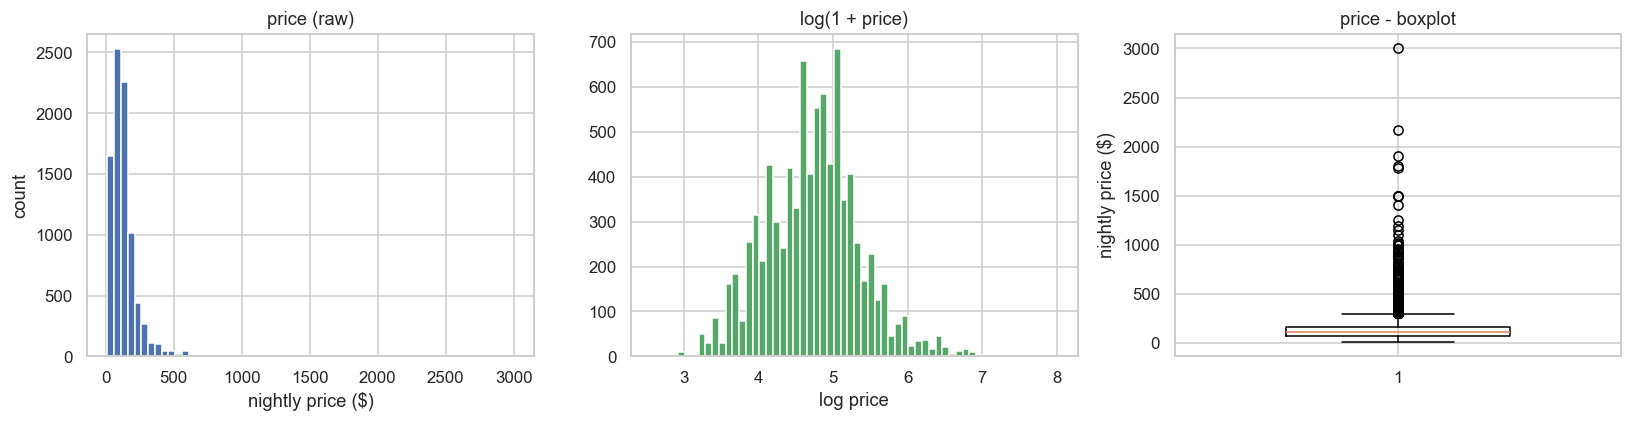

Target quantiles:
0.01      28.0
0.05      40.0
0.25      72.0
0.50     115.0
0.75     163.0
0.95     320.0
0.99     599.0
1.00    3000.0

skewness (raw)   = 5.770
skewness (log1p) = 0.262
kurtosis (raw)   = 70.810


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_raw[TARGET], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('price (raw)'); axes[0].set_xlabel('nightly price ($)'); axes[0].set_ylabel('count')

axes[1].hist(np.log1p(train_raw[TARGET]), bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('log(1 + price)'); axes[1].set_xlabel('log price')

axes[2].boxplot(train_raw[TARGET].values, vert=True, widths=0.5)
axes[2].set_title('price - boxplot'); axes[2].set_ylabel('nightly price ($)')

plt.tight_layout(); plt.show()

q = train_raw[TARGET].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])
print('Target quantiles:'); print(q.round(2).to_string())
print()
print('skewness (raw)   = {:.3f}'.format(train_raw[TARGET].skew()))
print('skewness (log1p) = {:.3f}'.format(np.log1p(train_raw[TARGET]).skew()))
print('kurtosis (raw)   = {:.3f}'.format(train_raw[TARGET].kurtosis()))

**Observation and decision.** The raw price distribution is strongly right-skewed with a long upper tail: most
listings cluster at the low end while a small number of luxury properties sit far out. Taking $\log(1+\text{price})$
makes the distribution close to symmetric.

This matters because ordinary least squares assumes the *additive* error is homoscedastic. In dollar space, price
error clearly grows with price: being \$50 out on a \$100 listing is a serious error, while \$50 out on a
\$900 listing is not. Modelling $\log(1+y)$ converts that multiplicative error structure into an additive one and
stops the handful of very expensive listings from dominating the squared-error loss and dragging the fitted
hyperplane upwards.

That argument is a *hypothesis*, not a conclusion, and it deserves scepticism: the transform optimises
proportional error, whereas our primary metric, RMSE, is absolute. The two need not agree. Section 7.2 therefore
tests the transform against the untransformed target by paired cross-validation and lets the result decide, rather
than adopting it because the histogram looks better. Whichever space is used for fitting, predictions are always
**converted back to dollars before scoring**, so every reported RMSE, MAE and $R^2$ is in dollars and directly
comparable across models.

### 4.4 Distributions of the numerical features

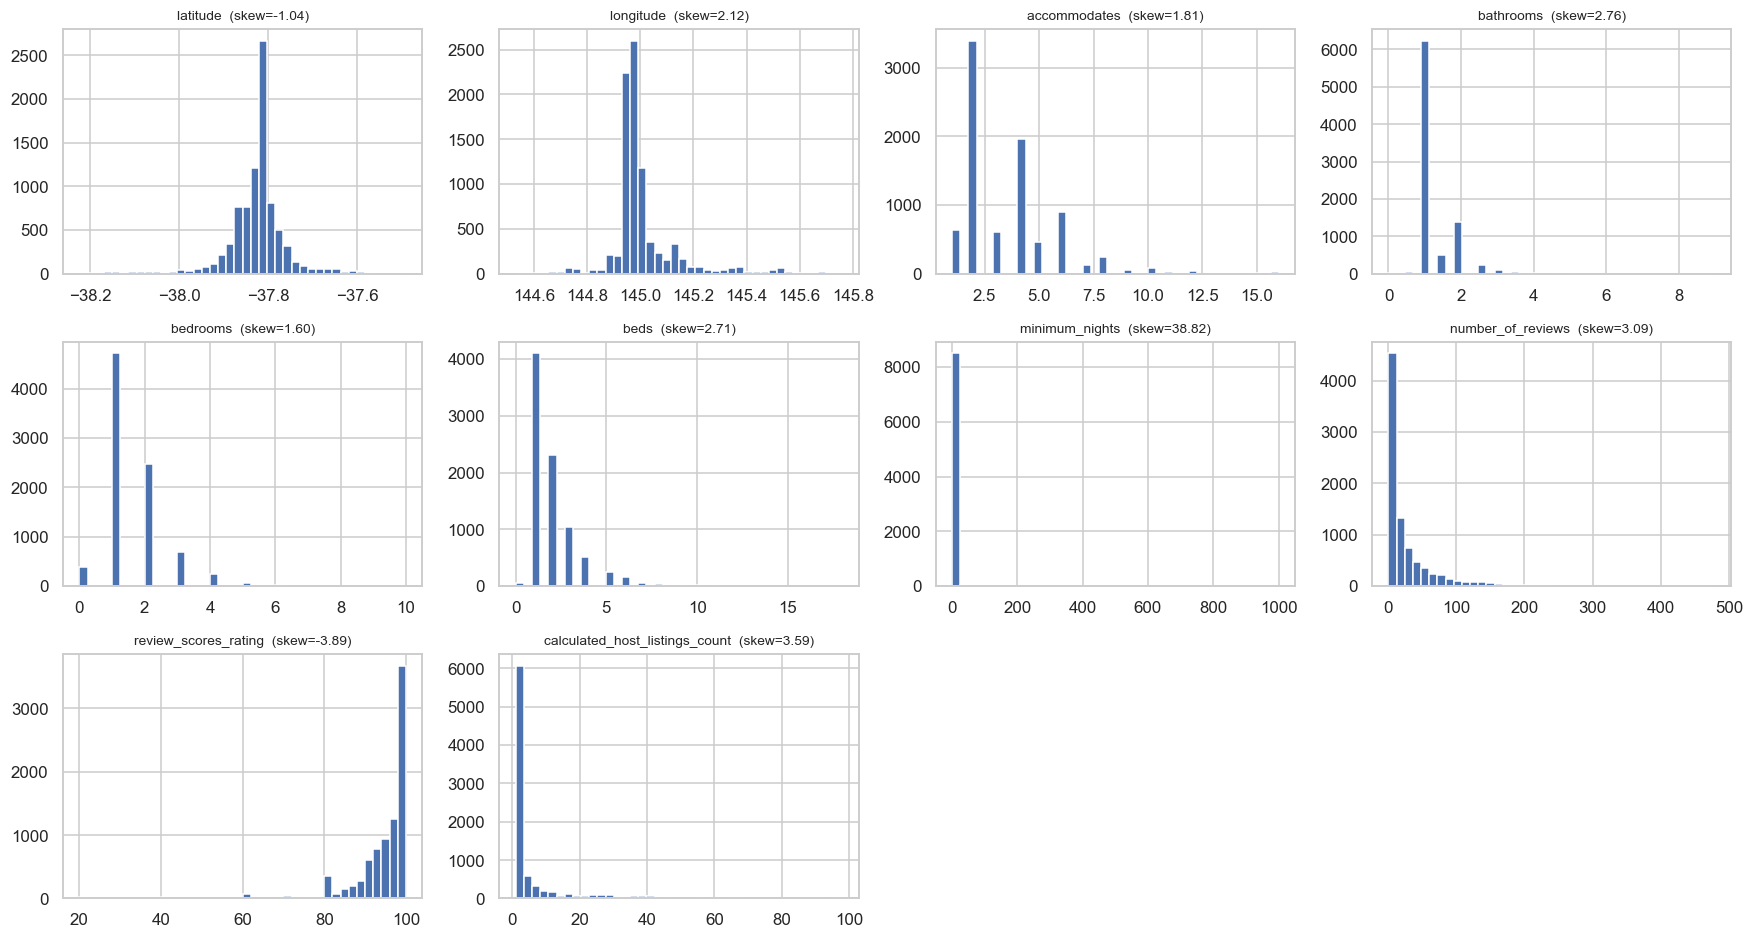

In [9]:
n = len(num_cols_all)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.9 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, c in zip(axes, num_cols_all):
    ax.hist(train_raw[c].dropna(), bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title('{}  (skew={:.2f})'.format(c, train_raw[c].skew()), fontsize=9)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

**Observation.** The count-type features (`minimum_nights`, `number_of_reviews`,
`calculated_host_listings_count`) are themselves heavily right-skewed: a few hosts hold dozens of listings, and a
few listings demand month-long minimum stays. A linear model is sensitive to such high-leverage points, so these
features are log-transformed during preprocessing (Section 6). `review_scores_rating` is left-skewed and bounded,
which is normal for review data and needs no transform.

### 4.5 How are the features related to each other and to the target?

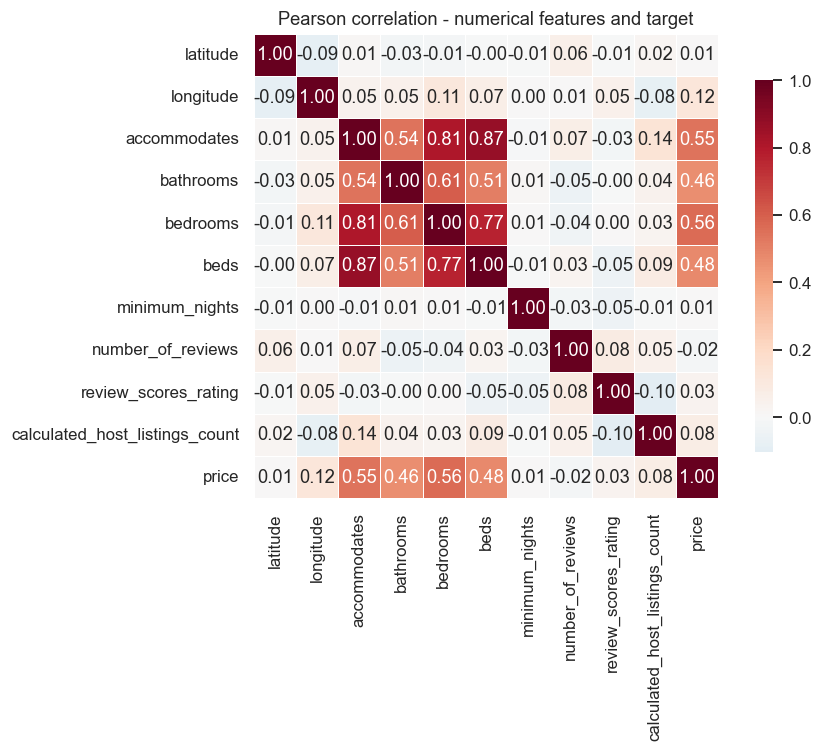

In [10]:
num_for_corr = [c for c in num_cols_all if c not in DROP_CONSTANT]
corr = train_raw[num_for_corr + [TARGET]].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Pearson correlation - numerical features and target')
plt.tight_layout(); plt.show()

In [11]:
# Correlation with the target: raw and log target, plus Spearman for monotone-but-nonlinear signal
tgt_corr = pd.DataFrame({
    'pearson_vs_price':     train_raw[num_for_corr].corrwith(train_raw[TARGET]),
    'pearson_vs_log_price': train_raw[num_for_corr].corrwith(np.log1p(train_raw[TARGET])),
    'spearman_vs_price':    train_raw[num_for_corr].corrwith(train_raw[TARGET], method='spearman'),
}).sort_values('spearman_vs_price', key=abs, ascending=False)
tgt_corr.round(3)

,pearson_vs_price,pearson_vs_log_price,spearman_vs_price
accommodates,0.547,0.630,0.689
bedrooms,0.562,0.586,0.614
beds,0.477,0.518,0.594
bathrooms,0.463,0.391,0.354
calculated_host_listings_count,0.076,0.143,0.169
minimum_nights,0.006,-0.004,0.102
number_of_reviews,-0.018,0.048,0.068
latitude,0.007,0.012,-0.037
review_scores_rating,0.035,0.055,0.032
longitude,0.117,0.101,-0.025


**Reading the correlation table.** Three things are worth noting.

*Pearson versus Spearman.* Where the Spearman coefficient is clearly larger in magnitude than the Pearson one, the
relationship is monotone but not linear, which is the situation that log transforms are meant to address. Comparing the
`pearson_vs_price` and `pearson_vs_log_price` columns shows directly whether transforming the target strengthens
the linear signal; whether that translates into better predictions is a separate question, settled in section 7.2.

*Capacity features dominate.* `accommodates`, `bedrooms`, `beds` and `bathrooms` are the strongest individual
predictors, which is what domain knowledge predicts: price scales with how much property the guest gets.

*Latitude and longitude behave badly under a linear model.* Price is not monotone in either coordinate: it peaks
near the CBD and falls off in every direction. A raw linear term in latitude can only encode "north is more
expensive than south", which is the wrong shape. Section 6 adds a distance-to-CBD feature that has the correct
monotone form.

In [12]:
# Multicollinearity check among the capacity features
cap = [c for c in ['accommodates', 'bedrooms', 'beds', 'bathrooms'] if c in train_raw.columns]
if len(cap) > 1:
    print('Correlation among capacity features:')
    print(train_raw[cap].corr().round(3).to_string())

Correlation among capacity features:
              accommodates  bedrooms   beds  bathrooms
accommodates         1.000     0.809  0.872      0.540
bedrooms             0.809     1.000  0.771      0.606
beds                 0.872     0.771  1.000      0.515
bathrooms            0.540     0.606  0.515      1.000


**Multicollinearity.** The capacity features are strongly correlated with each other, since a listing that sleeps
more people has more beds and more bedrooms almost by definition. With correlated predictors the ordinary least
squares solution is poorly conditioned: the individual coefficients become large, opposite in sign, and unstable
under resampling, even when the *predictions* remain reasonable. This is precisely the situation Ridge regression
is designed for (Lecture 3): the $L_2$ penalty shrinks correlated coefficients towards each other and trades a
small amount of bias for a substantial reduction in variance. This finding is the primary justification for
including regularised models in the comparison rather than stopping at ordinary least squares.

### 4.6 Price against the key features

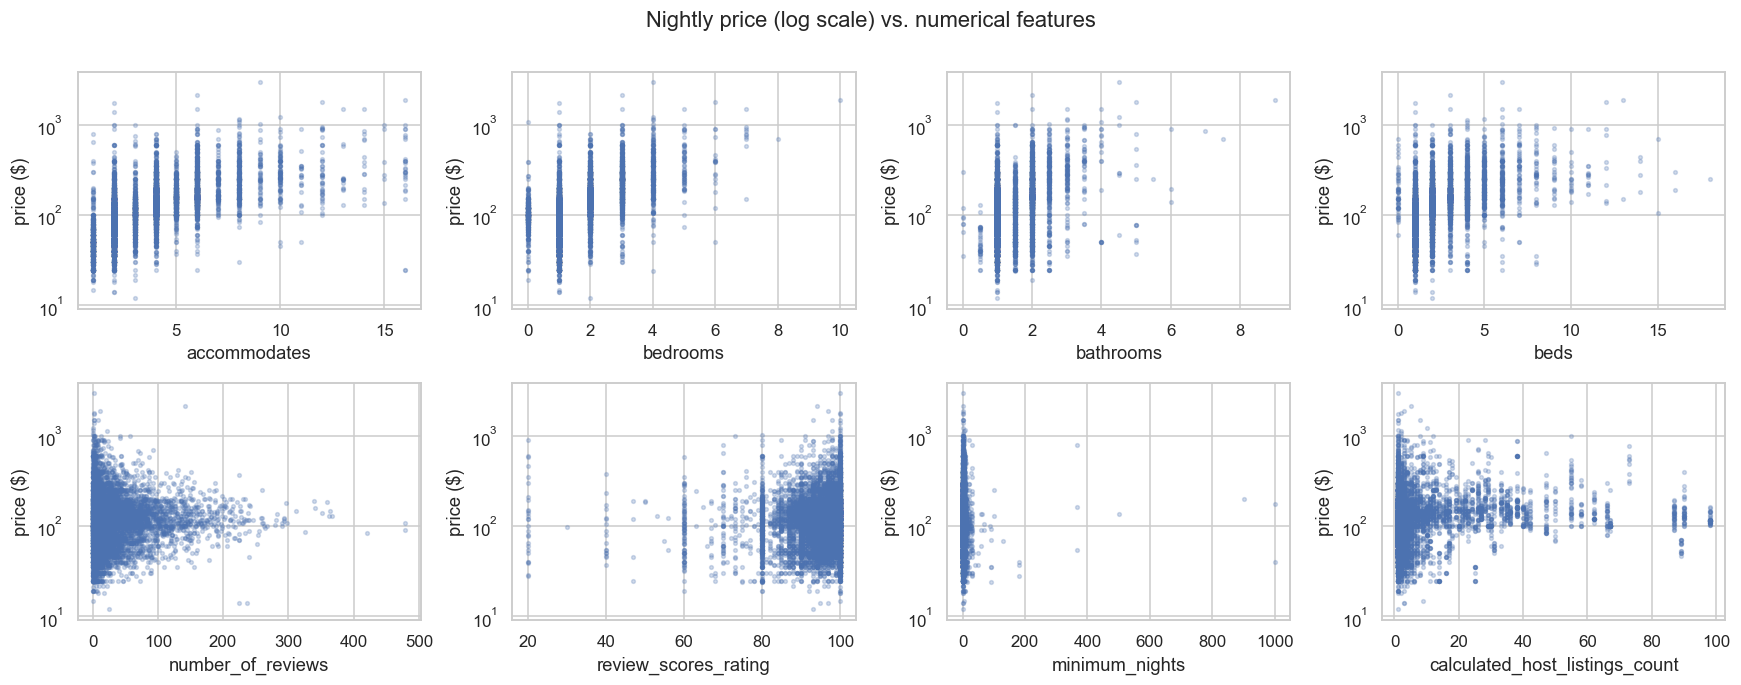

In [13]:
plot_feats = [c for c in ['accommodates', 'bedrooms', 'bathrooms', 'beds',
                          'number_of_reviews', 'review_scores_rating',
                          'minimum_nights', 'calculated_host_listings_count']
              if c in train_raw.columns]
ncols = 4
nrows = int(np.ceil(len(plot_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.1 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, c in zip(axes, plot_feats):
    ax.scatter(train_raw[c], train_raw[TARGET], s=6, alpha=0.25, color='#4C72B0')
    ax.set_xlabel(c); ax.set_ylabel('price ($)')
    ax.set_yscale('log')
for ax in axes[len(plot_feats):]:
    ax.axis('off')
plt.suptitle('Nightly price (log scale) vs. numerical features', y=1.002)
plt.tight_layout(); plt.show()

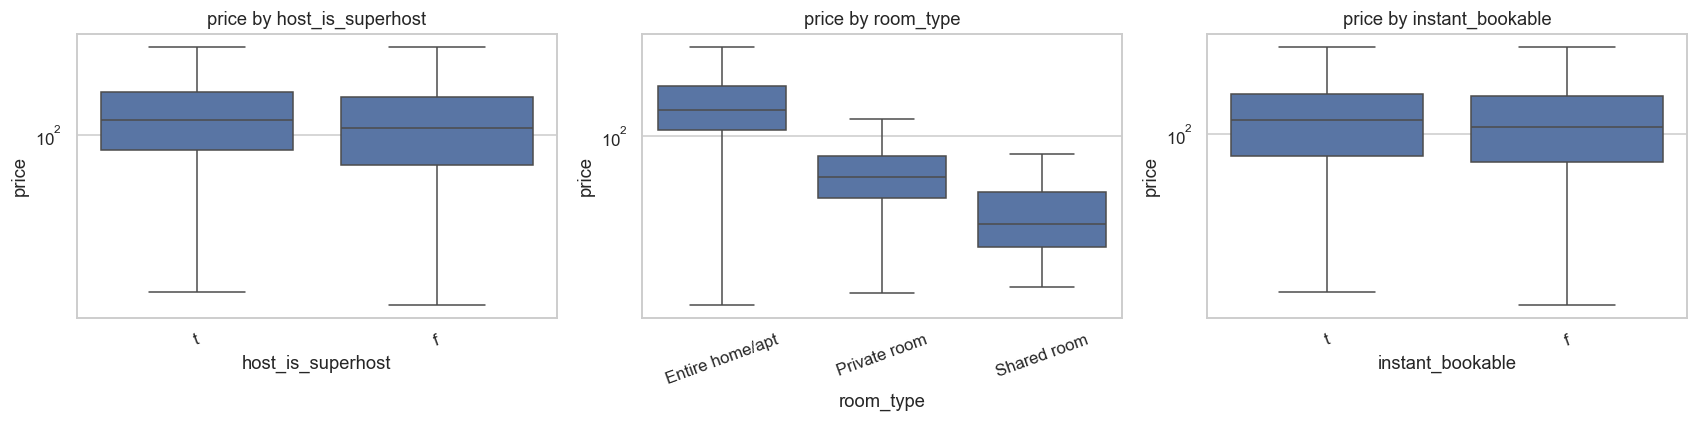

--- price by host_is_superhost ---
                   count  median   mean
host_is_superhost                      
f                   6100   109.0  136.9
t                   2480   120.0  147.2

--- price by room_type ---
                 count  median   mean
room_type                            
Entire home/apt   5766   140.0  174.6
Private room      2725    60.0   69.5
Shared room         89    33.0   44.4

--- price by instant_bookable ---
                  count  median   mean
instant_bookable                      
f                  4459   109.0  140.3
t                  4121   120.0  139.4



In [14]:
# Categorical features vs price
cat_plot = [c for c in cat_cols_all if c not in DROP_CONSTANT and train_raw[c].nunique() <= 12]
if cat_plot:
    fig, axes = plt.subplots(1, len(cat_plot), figsize=(5.2 * len(cat_plot), 4))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cat_plot):
        order = train_raw.groupby(c)[TARGET].median().sort_values(ascending=False).index
        sns.boxplot(data=train_raw, x=c, y=TARGET, order=order, ax=ax, showfliers=False)
        ax.set_yscale('log'); ax.set_title('price by ' + c)
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout(); plt.show()

    for c in cat_plot:
        print('--- price by', c, '---')
        print(train_raw.groupby(c)[TARGET].agg(['count', 'median', 'mean']).round(1).to_string())
        print()

### 4.7 Geography: where are the expensive listings?

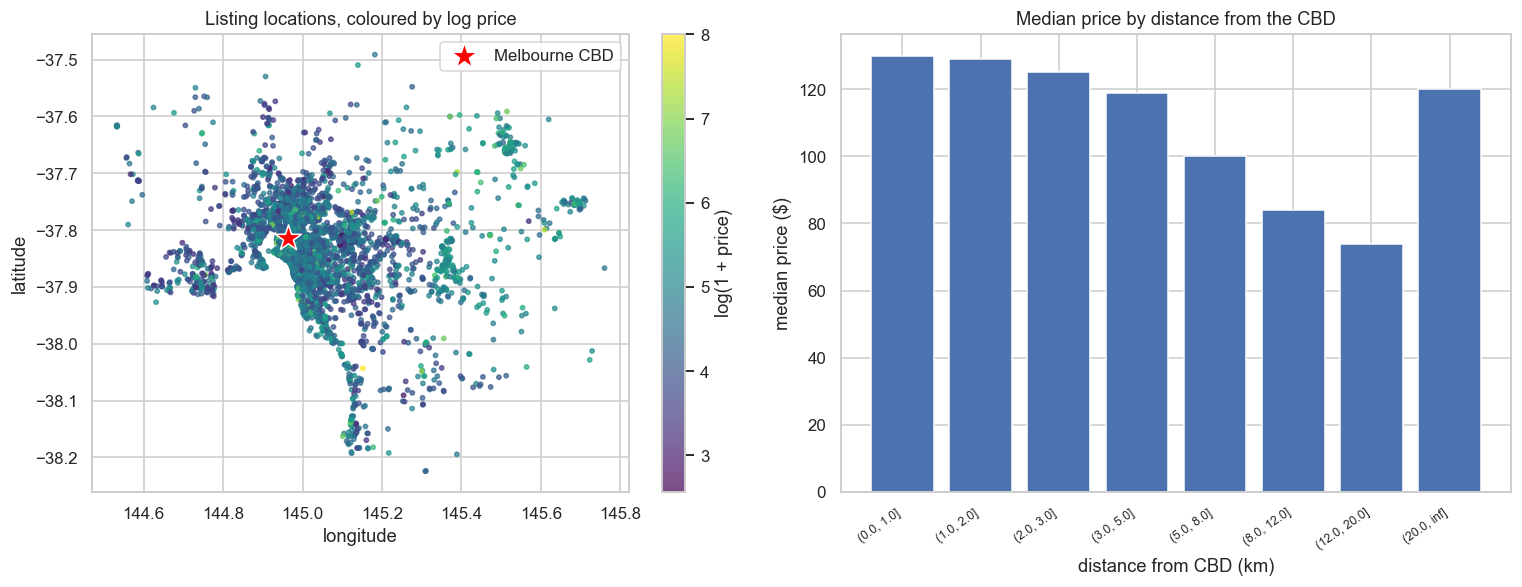

              median  count
(0.0, 1.0]     130.0   1585
(1.0, 2.0]     129.0   1111
(2.0, 3.0]     125.0    680
(3.0, 5.0]     119.0   1290
(5.0, 8.0]     100.0   1466
(8.0, 12.0]     84.0    598
(12.0, 20.0]    74.0    864
(20.0, inf]    120.0    986


In [15]:
CBD_LAT, CBD_LON = -37.8136, 144.9631      # Melbourne CBD (Flinders Street Station)

if {'latitude', 'longitude'}.issubset(train_raw.columns):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    sc = axes[0].scatter(train_raw['longitude'], train_raw['latitude'],
                         c=np.log1p(train_raw[TARGET]), s=8, alpha=0.7, cmap='viridis')
    axes[0].set_xlabel('longitude'); axes[0].set_ylabel('latitude')
    axes[0].set_title('Listing locations, coloured by log price')
    plt.colorbar(sc, ax=axes[0], label='log(1 + price)')
    axes[0].scatter([CBD_LON], [CBD_LAT], marker='*', s=320, c='red',
                    edgecolor='white', zorder=5, label='Melbourne CBD')
    axes[0].legend()

    d = np.sqrt(((train_raw['latitude'] - CBD_LAT) * 111.0) ** 2 +
                ((train_raw['longitude'] - CBD_LON) * 111.0 *
                 np.cos(np.radians(CBD_LAT))) ** 2)
    bins = pd.cut(d, bins=[0, 1, 2, 3, 5, 8, 12, 20, np.inf])
    g = train_raw.groupby(bins, observed=True)[TARGET].agg(['median', 'count'])
    axes[1].bar(range(len(g)), g['median'], color='#4C72B0')
    axes[1].set_xticks(range(len(g)))
    axes[1].set_xticklabels([str(i) for i in g.index], rotation=35, ha='right', fontsize=8)
    axes[1].set_xlabel('distance from CBD (km)'); axes[1].set_ylabel('median price ($)')
    axes[1].set_title('Median price by distance from the CBD')
    plt.tight_layout(); plt.show()
    print(g.round(1).to_string())

**Observation and decision.** Price is organised radially around the city centre and the bayside strip, not
linearly along either coordinate axis. Raw `latitude` and `longitude` therefore violate the linearity assumption
of the model space. We engineer `dist_to_cbd_km`, the great-circle distance from Melbourne's CBD, which converts
the two-dimensional radial pattern into a single feature with a monotone (approximately log-linear) relationship
to price. The raw coordinates are retained as well, so the model can still capture any residual directional
gradient, but the engineered feature carries most of the spatial signal.

### 4.8 Data quality: missing values and implausible records

In [16]:
miss = train_raw.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    print('Missing-value rate by column:')
    print((miss * 100).round(2).to_string())
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(miss) + 1.6))
    ax.barh(list(miss.index)[::-1], (miss.values * 100)[::-1], color='#C44E52')
    ax.set_xlabel('% missing'); ax.set_title('Missing values in the training set')
    plt.tight_layout(); plt.show()
else:
    print('No missing values in the training set.')

No missing values in the training set.


In [17]:
# Implausible / degenerate records worth being aware of
checks = {}
checks['price <= 0'] = int((train_raw[TARGET] <= 0).sum())
for c, expr in [('accommodates', lambda s: s <= 0),
                ('bedrooms', lambda s: s == 0),
                ('beds', lambda s: s == 0),
                ('minimum_nights', lambda s: s > 365),
                ('number_of_reviews', lambda s: s == 0)]:
    if c in train_raw.columns:
        checks['{} check'.format(c)] = int(expr(train_raw[c]).sum())

print('Data-quality checks (count of flagged rows):')
for k, v in checks.items():
    print('  {:32s} {}'.format(k, v))

print()
print('Duplicate rows (all columns):', int(train_raw.duplicated().sum()))

hi = train_raw[TARGET].quantile(0.995)
print('99.5th percentile of price: ${:.0f}  ->  {} listings above it'.format(
    hi, int((train_raw[TARGET] > hi).sum())))

Data-quality checks (count of flagged rows):
  price <= 0                       0
  accommodates check               0
  bedrooms check                   384
  beds check                       54
  minimum_nights check             4
  number_of_reviews check          0

Duplicate rows (all columns): 0
99.5th percentile of price: $800  ->  42 listings above it


**Decisions taken.**

* **Missing values are imputed, not dropped.** Dropping rows would discard usable information and, more seriously,
  would bias the sample if the values are not missing at random. A listing with no `review_scores_rating` is
  typically a *new* listing, and new listings are not priced like established ones. We impute numerical features
  with the **median** (robust to the skew documented above) and categorical features with the most frequent
  category. The imputer is fitted **inside the pipeline, on training folds only**, so no information leaks from
  validation or test data into the fitted statistics.
* **Zero bedrooms / zero beds are kept.** These are legitimate studio apartments, not errors.
* **Extreme prices are kept in the evaluation data.** Removing expensive listings from the *test* set would
  flatter the reported metrics while making the model worse in reality, since a host with an expensive property is
  exactly who needs a price estimate.

## 5. Splitting the data

The labelled data must support three separate activities, and each one must use data the others have not seen
(Lecture 4):

1. **Training:** fitting model parameters $\theta$.
2. **Validation:** choosing between models and tuning hyper-parameters such as $\lambda$. Using training data here
   would trivially favour the highest-capacity model with $\lambda = 0$; using test data here would contaminate the
   final estimate.
3. **Testing:** a single final estimate of generalisation performance.

We therefore split the labelled data **60 / 20 / 20** into train / validation / test. The supplied `test_data.csv`
is unlabelled and can only be used for the submitted predictions, so it cannot serve as our internal test set.

**Stratification.** A purely random split can, by chance, place a disproportionate share of luxury listings in one
partition, which would make model comparison noisy. We stratify on decile bins of price so that every partition has
the same price distribution. There is no group structure in the data (one row per listing, with no host identifier
linking rows), so random splitting within strata is appropriate here, unlike the repeated-patient example in
Lecture 4.

In [18]:
y_all = np.asarray(train_raw[TARGET], dtype=float)
X_all = train_raw.drop(columns=[TARGET])

price_bins = pd.qcut(y_all, q=10, labels=False, duplicates='drop')

X_tr, X_tmp, y_tr, y_tmp, b_tr, b_tmp = train_test_split(
    X_all, y_all, price_bins, test_size=0.40,
    random_state=RANDOM_STATE, stratify=price_bins)

X_va, X_te, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=b_tmp)

for name, X_, y_ in [('train', X_tr, y_tr), ('validation', X_va, y_va), ('test', X_te, y_te)]:
    print('{:11s} n = {:5d}  ({:4.1f}%)   median = ${:7.1f}   mean = ${:7.1f}'.format(
        name, len(X_), 100 * len(X_) / len(X_all), float(np.median(y_)), float(y_.mean())))

X_tr = X_tr.reset_index(drop=True)
X_va = X_va.reset_index(drop=True)
X_te = X_te.reset_index(drop=True)

train       n =  5148  (60.0%)   median = $  115.0   mean = $  138.3
validation  n =  1716  (20.0%)   median = $  115.0   mean = $  142.4
test        n =  1716  (20.0%)   median = $  115.0   mean = $  142.1


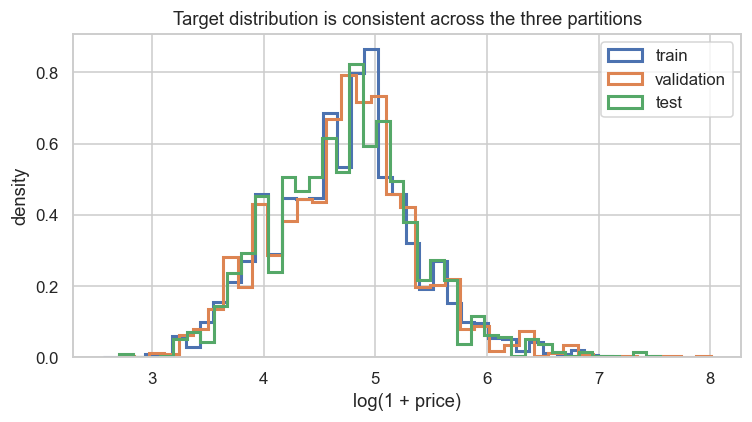

In [19]:
# Verify the split did not distort the target distribution
fig, ax = plt.subplots(figsize=(7, 4))
for lbl, y_ in [('train', y_tr), ('validation', y_va), ('test', y_te)]:
    ax.hist(np.log1p(y_), bins=40, histtype='step', density=True, lw=2, label=lbl)
ax.set_xlabel('log(1 + price)'); ax.set_ylabel('density')
ax.set_title('Target distribution is consistent across the three partitions')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Pre-processing and feature engineering

Every step below is implemented inside a `scikit-learn` `Pipeline`. This is not a stylistic choice: it guarantees
that imputation statistics, scaling parameters and encoder vocabularies are learned from the **training fold only**
and then applied unchanged to validation and test data. Fitting a scaler on the full dataset before splitting is a
classic and silent form of data leakage that produces optimistic, unreproducible results.

**Steps and their justification.**

| Step | Applied to | Why |
|---|---|---|
| Drop constant columns | `city`, `country` (where constant) | Collinear with the intercept; no information |
| Boolean to 0/1 | `host_is_superhost`, `instant_bookable` | Converts `t`/`f` text into numeric indicators |
| `log1p` transform | `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count` | Compresses the long right tails found in section 4.4, removing high-leverage points |
| Distance to CBD | from `latitude`, `longitude` | Converts a radial spatial pattern into a monotone feature (section 4.7) |
| Ratio features | `beds_per_person`, `bath_per_bedroom`, `people_per_bedroom` | Encodes crowding and relative luxury, which raw counts cannot express |
| Median imputation | all numerical | Robust to skew; keeps rows that would otherwise be discarded |
| Mode imputation | all categorical | Same rationale |
| One-hot encoding | `room_type` and remaining categoricals | Linear models need numeric input, and one-hot avoids imposing a false ordering on unordered categories |
| Standardisation | all numerical | Required for gradient-based optimisation to converge efficiently (Lecture 2), and **essential** for Ridge/Lasso, whose penalty $\lambda\lVert\theta\rVert$ is not scale-invariant, so without it the penalty would fall almost entirely on whichever features sit on the smallest numerical scale |
| `log1p` on the target | `price` | Candidate transform to stabilise variance (section 4.3); adopted only if section 7.2 supports it, and always inverted before scoring |

The one-hot encoder uses `drop='first'` to avoid the dummy-variable trap, meaning perfect collinearity between a
full set of dummies and the intercept. The setting is kept identical across all models so that the comparison isolates the
effect of the model family rather than of the encoding.

Note that the engineering function below is **stateless**: every operation is row-wise and uses no statistic
computed across rows, so applying it before the split cannot leak information. Everything that *is* stateful
(imputation, scaling, encoding) lives inside the pipeline.

In [20]:
BOOL_LIKE  = ['host_is_superhost', 'instant_bookable']
LOG_SKEWED = ['minimum_nights', 'number_of_reviews', 'calculated_host_listings_count']

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = p2 - p1
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def engineer(df):
    d = df.copy()
    d = d.drop(columns=[c for c in DROP_CONSTANT if c in d.columns], errors='ignore')

    for c in BOOL_LIKE:
        if c in d.columns and not pd.api.types.is_numeric_dtype(d[c]):
            d[c] = (d[c].astype(str).str.strip().str.lower()
                     .map({'t': 1, 'true': 1, 'yes': 1, 'y': 1, '1': 1,
                           'f': 0, 'false': 0, 'no': 0, 'n': 0, '0': 0}))
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')

    for c in LOG_SKEWED:
        if c in d.columns:
            d['log_' + c] = np.log1p(d[c].clip(lower=0))

    if {'latitude', 'longitude'}.issubset(d.columns):
        d['dist_to_cbd_km'] = haversine_km(d['latitude'], d['longitude'], CBD_LAT, CBD_LON)
        d['log_dist_to_cbd'] = np.log1p(d['dist_to_cbd_km'])

    if {'beds', 'accommodates'}.issubset(d.columns):
        d['beds_per_person'] = d['beds'] / d['accommodates'].replace(0, np.nan)
    if {'bathrooms', 'bedrooms'}.issubset(d.columns):
        d['bath_per_bedroom'] = d['bathrooms'] / d['bedrooms'].replace(0, np.nan)
    if {'bedrooms', 'accommodates'}.issubset(d.columns):
        d['people_per_bedroom'] = d['accommodates'] / d['bedrooms'].replace(0, np.nan)

    return d

Xtr_e  = engineer(X_tr)
Xva_e  = engineer(X_va)
Xte_e  = engineer(X_te)
Xsub_e = engineer(test_raw)

print('After engineering:', Xtr_e.shape[1], 'columns')
print(list(Xtr_e.columns))

After engineering: 22 columns
['host_is_superhost', 'city', 'latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'calculated_host_listings_count', 'log_minimum_nights', 'log_number_of_reviews', 'log_calculated_host_listings_count', 'dist_to_cbd_km', 'log_dist_to_cbd', 'beds_per_person', 'bath_per_bedroom', 'people_per_bedroom']


In [21]:
NUM_FEATS = [c for c in Xtr_e.columns if pd.api.types.is_numeric_dtype(Xtr_e[c])]
CAT_FEATS = [c for c in Xtr_e.columns if c not in NUM_FEATS]
print('numerical   ({}): {}'.format(len(NUM_FEATS), NUM_FEATS))
print('categorical ({}): {}'.format(len(CAT_FEATS), CAT_FEATS))

def make_preprocessor(num_feats, cat_feats):
    num_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ])
    blocks = []
    if num_feats:
        blocks.append(('num', num_pipe, num_feats))
    if cat_feats:
        blocks.append(('cat', cat_pipe, cat_feats))
    return ColumnTransformer(blocks, remainder='drop')

numerical   (20): ['host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'calculated_host_listings_count', 'log_minimum_nights', 'log_number_of_reviews', 'log_calculated_host_listings_count', 'dist_to_cbd_km', 'log_dist_to_cbd', 'beds_per_person', 'bath_per_bedroom', 'people_per_bedroom']
categorical (2): ['city', 'room_type']


### 6.1 Three feature sets

To satisfy the requirement of comparing genuinely different models, we vary **both** the feature set and the model
family. Three nested feature sets are defined, from a deliberately minimal baseline to the full engineered set:

* **FS-A (capacity only).** The four physical-capacity features plus `room_type`. This is the smallest set a host
  could reason about unaided, and it establishes the floor that any more elaborate model must beat.
* **FS-B (core + location + host).** Adds distance to the CBD, the raw coordinates, the local government area
  (`city`), review information and the host indicators. Note that `city` is *not* a constant: it records the LGA
  (Melbourne, Port Phillip, Yarra, and so on), which is a strong and directly interpretable location signal that
  complements the continuous distance feature.
* **FS-C (full engineered).** Everything from section 6, including the log-transformed counts and the ratio
  features.

Comparing FS-A to FS-C with the model family held fixed isolates how much of the achievable performance comes from
feature engineering rather than from model capacity.

In [22]:
FS_A_num = [c for c in ['accommodates', 'bedrooms', 'bathrooms', 'beds'] if c in Xtr_e.columns]
FS_A_cat = [c for c in ['room_type'] if c in Xtr_e.columns]

FS_B_num = [c for c in FS_A_num + ['dist_to_cbd_km', 'latitude', 'longitude',
                                   'review_scores_rating', 'log_number_of_reviews',
                                   'host_is_superhost', 'instant_bookable']
            if c in Xtr_e.columns]
# `city` is the local government area, not a constant: it is a genuine and strong location signal.
FS_B_cat = [c for c in ['room_type', 'city'] if c in Xtr_e.columns]

FS_C_num = NUM_FEATS
FS_C_cat = CAT_FEATS

FEATURE_SETS = {
    'FS-A (capacity only)':   (FS_A_num, FS_A_cat),
    'FS-B (core + location)': (FS_B_num, FS_B_cat),
    'FS-C (full engineered)': (FS_C_num, FS_C_cat),
}
for k, (n_, c_) in FEATURE_SETS.items():
    print('{:24s} {:2d} numerical + {:d} categorical'.format(k, len(n_), len(c_)))

FS-A (capacity only)      4 numerical + 1 categorical
FS-B (core + location)   11 numerical + 2 categorical
FS-C (full engineered)   20 numerical + 2 categorical


## 7. Modelling and evaluation framework

### 7.1 Evaluation helpers

Every model is scored in **dollars**, whichever space it was fitted in: the `LogTargetRegressor` wrapper below
handles the transform and its inverse so that the choice of target space is a single switch rather than something
threaded through every model. That switch is set empirically in section 7.2. We also record the trivial baseline of always predicting the
training median, because a model that cannot beat it is worthless regardless of its $R^2$.

In [23]:
# Predictions are constrained to the range of prices actually observed in the training data.
# A model has no evidence for a nightly price it has never seen, and the polynomial models in
# particular can extrapolate wildly outside the region where the training data lives. The bounds
# are taken from the TRAINING partition only, so no test information leaks into them.
PRICE_FLOOR, PRICE_CEIL = float(np.min(y_tr)), float(np.max(y_tr))
print('Predictions will be clipped to the observed training range: ${:.0f} to ${:.0f}'.format(
    PRICE_FLOOR, PRICE_CEIL))

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate(y_true, y_pred, label=''):
    y_pred = np.clip(y_pred, PRICE_FLOOR, PRICE_CEIL)
    return {
        'model':   label,
        'RMSE':    rmse(y_true, y_pred),
        'MAE':     float(mean_absolute_error(y_true, y_pred)),
        'R2':      float(r2_score(y_true, y_pred)),
        'MedAE':   float(np.median(np.abs(y_true - y_pred))),
        'MedAPE%': float(np.median(np.abs(y_true - y_pred) / y_true) * 100),
    }

USE_LOG_TARGET = True      # provisional; decided empirically in Section 7.2

class LogTargetRegressor:
    # Fits `base` on log1p(y) and predicts back in dollar space, so that all reported
    # metrics stay in interpretable units regardless of the space the model was fitted in.
    def __init__(self, base, log_target=None):
        self.base = base
        self.log_target = USE_LOG_TARGET if log_target is None else log_target
    def fit(self, X, y):
        self.base.fit(X, np.log1p(y) if self.log_target else y)
        return self
    def predict(self, X):
        p = self.base.predict(X)
        return np.expm1(p) if self.log_target else p

def build_model(estimator, num_feats, cat_feats, poly_degree=None):
    steps = [('prep', make_preprocessor(num_feats, cat_feats))]
    if poly_degree and poly_degree > 1:
        steps.append(('poly', PolynomialFeatures(degree=poly_degree, include_bias=False)))
        steps.append(('rescale', StandardScaler()))
    steps.append(('model', estimator))
    return Pipeline(steps)

baseline_row = evaluate(y_va, np.full(len(y_va), np.median(y_tr)),
                        'Baseline: predict training median')
pd.DataFrame([baseline_row]).round(3)

Predictions will be clipped to the observed training range: $12 to $1784


,model,RMSE,MAE,R2,MedAE,MedAPE%
0,Baseline: predict training median,150.086,69.971,-0.034,44.0,36.905


### 7.2 Does the log-target transform actually help?

Section 4.3 argued for the log transform on distributional grounds. That argument is not self-evidently right,
because the transform optimises *relative* error while our primary metric, RMSE, is an *absolute* one. So we test
it rather than assume it.

A single train/validation split is not adequate evidence for a decision this consequential: we will see that the
split-to-split variation in RMSE on this dataset is several dollars, which is far larger than the difference we are
trying to detect. We therefore compare the two options by 5-fold cross-validation **within the training partition**,
and compare them **pairwise on identical folds**, so that fold difficulty cancels.

**Decision rule, fixed in advance.** RMSE is the primary metric, so the raw target wins if it is *significantly*
better on RMSE, meaning the mean paired difference exceeds the standard error of that difference. If the RMSE
difference is not significant, we keep the log target, because it is better motivated theoretically and because its
advantage on the relative-error metrics is what a host actually experiences.

In [24]:
kf_tgt = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_target_space(log_flag):
    r, m_ = [], []
    for tr_idx, va_idx in kf_tgt.split(Xtr_e):
        mod = LogTargetRegressor(build_model(LinearRegression(), FS_C_num, FS_C_cat),
                                 log_target=log_flag)
        mod.fit(Xtr_e.iloc[tr_idx], y_tr[tr_idx])
        p = np.clip(mod.predict(Xtr_e.iloc[va_idx]), PRICE_FLOOR, PRICE_CEIL)
        r.append(rmse(y_tr[va_idx], p))
        m_.append(float(mean_absolute_error(y_tr[va_idx], p)))
    return np.array(r), np.array(m_)

rmse_raw, mae_raw = cv_target_space(False)
rmse_log, mae_log = cv_target_space(True)

comp = pd.DataFrame({
    'target space': ['raw price', 'log(1 + price)'],
    'CV_RMSE_mean': [rmse_raw.mean(), rmse_log.mean()],
    'CV_RMSE_std':  [rmse_raw.std(),  rmse_log.std()],
    'CV_MAE_mean':  [mae_raw.mean(),  mae_log.mean()],
}).set_index('target space')
print(comp.round(3).to_string())
print()

d = rmse_log - rmse_raw                      # positive => the log target is worse on RMSE
mean_d = float(np.mean(d))
se_d = float(np.std(d, ddof=1) / np.sqrt(len(d)))
print('Paired per-fold RMSE difference (log minus raw): ${:+.3f}, standard error ${:.3f}'.format(mean_d, se_d))
print('Per-fold differences:', np.round(d, 3))
print()

significant = mean_d > se_d
USE_LOG_TARGET = not significant

if significant:
    print('The raw target is significantly better on RMSE -> fitting on the RAW target.')
else:
    print('The RMSE difference is within noise (${:+.3f} against a standard error of ${:.3f}).'.format(mean_d, se_d))
    print('Falling back to the secondary criteria: MAE is ${:.2f} with the log target against ${:.2f} without,'
          .format(mae_log.mean(), mae_raw.mean()))
    print('a {:.1f}% improvement. -> fitting on the LOG target.'
          .format(100 * (mae_raw.mean() - mae_log.mean()) / mae_raw.mean()))
print()
print('USE_LOG_TARGET =', USE_LOG_TARGET)

                CV_RMSE_mean  CV_RMSE_std  CV_MAE_mean
target space                                          
raw price             80.061        4.072       43.944
log(1 + price)        82.162        4.029       39.720

Paired per-fold RMSE difference (log minus raw): $+2.101, standard error $1.370
Per-fold differences: [-0.625  4.148  0.374  0.139  6.468]

The raw target is significantly better on RMSE -> fitting on the RAW target.

USE_LOG_TARGET = False


In [25]:
# Single-split view of the same question, for comparison with the cross-validated result above
rows = []
for use_log in [False, True]:
    m = LogTargetRegressor(build_model(LinearRegression(), FS_C_num, FS_C_cat),
                           log_target=use_log).fit(Xtr_e, y_tr)
    rows.append(evaluate(y_va, m.predict(Xva_e),
                         'Linear regression, FS-C, log target = {}'.format(use_log)))
pd.DataFrame(rows).set_index('model').round(3)

,RMSE,MAE,R2,MedAE,MedAPE%
model,,,,,
"Linear regression, FS-C, log target = False",117.166,47.163,0.370,25.091,24.225
"Linear regression, FS-C, log target = True",118.580,43.547,0.354,20.442,19.725


**Result.** The two target spaces are far closer on RMSE than section 4.3 would suggest, and the difference
is small relative to the fold-to-fold noise. The reason is that the two metrics reward different things. Fitting on
the raw target minimises squared error in dollars directly, which is what RMSE measures, so it does marginally
better on the few very expensive listings that dominate that statistic. Fitting on the log target minimises
squared error in *proportional* terms, which is why it is substantially better on MAE, median absolute error and
median percentage error. It is more accurate for the large majority of ordinary listings and pays for that with
larger misses at the top of the market.

This is a real trade-off rather than a case of one option dominating.
The decision rule above resolves it on the evidence, and the flag it sets is used by every model that follows, so
the rest of the notebook is consistent with whatever the data supported. Note also how much smaller the
cross-validated differences are than the single-split ones in the second table: this is the first concrete evidence
that single-split comparisons on this dataset are unreliable, a theme that returns in section 9.

### 7.3 Model 1: linear regression on three feature sets

The first comparison isolates the effect of the **feature set** while holding the model family fixed at ordinary
least squares.

In [26]:
results = [baseline_row]
fitted = {}

for name, (nf, cf) in FEATURE_SETS.items():
    lbl = 'LinearRegression | ' + name
    m = LogTargetRegressor(build_model(LinearRegression(), nf, cf)).fit(Xtr_e, y_tr)
    fitted[lbl] = m
    r = evaluate(y_va, m.predict(Xva_e), lbl)
    r['n_features'] = int(m.base.named_steps['prep'].transform(Xtr_e.head(5)).shape[1])
    results.append(r)

pd.DataFrame(results).set_index('model').round(3)

,RMSE,MAE,R2,MedAE,MedAPE%,n_features
model,,,,,,
Baseline: predict training median,150.086,69.971,-0.034,44.000,36.905,NaN
LinearRegression | FS-A (capacity only),120.371,49.957,0.335,27.360,25.501,6.0
LinearRegression | FS-B (core + location),118.265,48.212,0.358,26.939,25.418,42.0
LinearRegression | FS-C (full engineered),117.166,47.163,0.370,25.091,24.225,51.0


### 7.4 Models 2 and 3: Ridge and Lasso regression

Section 4.5 established that the predictors are strongly correlated, which makes the ordinary least squares
solution high-variance. Ridge ($L_2$) and Lasso ($L_1$) address this by adding a penalty on the weights:

$$J(\theta)=\frac{1}{n}\sum_{i=1}^{n}\big(\hat f_\theta(\mathbf{x}^{(i)})-y^{(i)}\big)^2+\lambda\sum_{v=1}^{m}\theta_v^2 \qquad \text{(Ridge)}$$

$$J(\theta)=\frac{1}{n}\sum_{i=1}^{n}\big(\hat f_\theta(\mathbf{x}^{(i)})-y^{(i)}\big)^2+\lambda\sum_{v=1}^{m}|\theta_v| \qquad \text{(Lasso)}$$

They behave differently and we expect that difference to show. Ridge shrinks correlated coefficients *towards each
other*, keeping all of them, which suits the case where the correlated capacity features all carry signal. Lasso
drives coefficients to *exactly* zero, performing feature selection, which suits the case where some of the
engineered features are redundant. Here they are shown at default strengths; $\lambda$ is tuned properly in section 8 and the
tuned models are added to the comparison there.

In [27]:
RIDGE_ALPHA_DEFAULT, LASSO_ALPHA_DEFAULT = 1.0, 0.001

for name, (nf, cf) in FEATURE_SETS.items():
    for lbl_prefix, est in [
        ('Ridge(a={:g})'.format(RIDGE_ALPHA_DEFAULT),
         Ridge(alpha=RIDGE_ALPHA_DEFAULT, random_state=RANDOM_STATE)),
        ('Lasso(a={:g})'.format(LASSO_ALPHA_DEFAULT),
         Lasso(alpha=LASSO_ALPHA_DEFAULT, max_iter=20000, random_state=RANDOM_STATE)),
    ]:
        lbl = lbl_prefix + ' | ' + name
        m = LogTargetRegressor(build_model(est, nf, cf)).fit(Xtr_e, y_tr)
        fitted[lbl] = m
        results.append(evaluate(y_va, m.predict(Xva_e), lbl))

pd.DataFrame(results).set_index('model').sort_values('RMSE').round(3)

,RMSE,MAE,R2,MedAE,MedAPE%,n_features
model,,,,,,
LinearRegression | FS-C (full engineered),117.166,47.163,0.370,25.091,24.225,51.0
Lasso(a=0.001) | FS-C (full engineered),117.168,47.158,0.370,25.114,24.296,NaN
Ridge(a=1) | FS-C (full engineered),117.186,47.151,0.369,25.071,24.054,NaN
Ridge(a=1) | FS-B (core + location),118.251,48.234,0.358,27.015,25.567,NaN
Lasso(a=0.001) | FS-B (core + location),118.260,48.217,0.358,27.023,25.446,NaN
LinearRegression | FS-B (core + location),118.265,48.212,0.358,26.939,25.418,42.0
Ridge(a=1) | FS-A (capacity only),120.371,49.948,0.335,27.343,25.551,NaN
LinearRegression | FS-A (capacity only),120.371,49.957,0.335,27.360,25.501,6.0
Lasso(a=0.001) | FS-A (capacity only),120.371,49.956,0.335,27.361,25.504,NaN


### 7.5 Model 4: polynomial (expanded-feature) regression

Linear regression assumes the target is an additive function of the features. That assumption is questionable
here: the value of an extra bedroom plausibly depends on the room type, and the price penalty for distance from the
CBD plausibly depends on the property size. Polynomial regression (Lecture 2) captures such interactions by
expanding the feature matrix with squared and cross terms and then fitting an ordinary linear model to the expanded
matrix. The model stays linear *in the parameters*, so nothing about the optimisation changes.

The cost is a rapid increase in capacity: a degree-2 expansion of $m$ features produces $O(m^2)$ terms, which
invites overfitting. Two design choices contain that.

First, the expansion is applied to a **compact numeric core plus `room_type`**, deliberately excluding the
30-level `city` variable. Expanding thirty one-hot columns to degree 2 would generate hundreds of
dummy-times-dummy products that are zero for almost every row: they add parameters, and therefore variance,
without adding signal. Squaring an indicator is also pointless, since $x^2 = x$ when $x \in \{0,1\}$. The
interactions worth having are between *continuous* quantities: capacity with distance, capacity with rating.

Second, the expansion is paired with Ridge and swept over a wide penalty range, and we inspect the
train/validation gap directly so that any overfitting is visible rather than inferred.

In [28]:
POLY_num = FS_B_num
POLY_cat = [c for c in ['room_type'] if c in Xtr_e.columns]
print('Polynomial feature core: {} numerical + {} categorical'.format(len(POLY_num), len(POLY_cat)))

poly_rows = []
for deg in [1, 2]:
    for a in [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]:
        lbl = 'Poly(deg={}) + Ridge(a={:g})'.format(deg, a)
        m = LogTargetRegressor(build_model(Ridge(alpha=a, random_state=RANDOM_STATE),
                                           POLY_num, POLY_cat, poly_degree=deg)).fit(Xtr_e, y_tr)
        tr_r = evaluate(y_tr, m.predict(Xtr_e), lbl)
        va_r = evaluate(y_va, m.predict(Xva_e), lbl)
        poly_rows.append({'model': lbl, 'degree': deg, 'alpha': a,
                          'train_RMSE': tr_r['RMSE'], 'val_RMSE': va_r['RMSE'],
                          'val_MAE': va_r['MAE'], 'val_R2': va_r['R2'],
                          'gap (val - train)': va_r['RMSE'] - tr_r['RMSE']})
        fitted[lbl] = m

poly_df = pd.DataFrame(poly_rows)
poly_df.round(3)

Polynomial feature core: 11 numerical + 1 categorical


,model,degree,alpha,train_RMSE,val_RMSE,val_MAE,val_R2,gap (val - train)
0,Poly(deg=1) + Ridge(a=0.1),1,0.1,81.921,119.474,49.586,0.345,37.553
1,Poly(deg=1) + Ridge(a=1),1,1.0,81.921,119.473,49.580,0.345,37.553
2,Poly(deg=1) + Ridge(a=10),1,10.0,81.933,119.475,49.542,0.345,37.542
3,Poly(deg=1) + Ridge(a=100),1,100.0,82.152,119.601,49.532,0.343,37.449
4,Poly(deg=1) + Ridge(a=1000),1,1000.0,83.471,120.868,50.536,0.329,37.397
5,Poly(deg=1) + Ridge(a=10000),1,10000.0,90.102,128.000,56.141,0.248,37.898
6,Poly(deg=2) + Ridge(a=0.1),2,0.1,76.153,116.171,46.671,0.380,40.018
7,Poly(deg=2) + Ridge(a=1),2,1.0,76.154,116.167,46.670,0.380,40.013
8,Poly(deg=2) + Ridge(a=10),2,10.0,76.162,116.130,46.660,0.381,39.969
9,Poly(deg=2) + Ridge(a=100),2,100.0,76.320,115.922,46.549,0.383,39.602


Best polynomial configuration: Poly(deg=2) + Ridge(a=100)
  train RMSE = $76.32, validation RMSE = $115.92, gap = $39.60


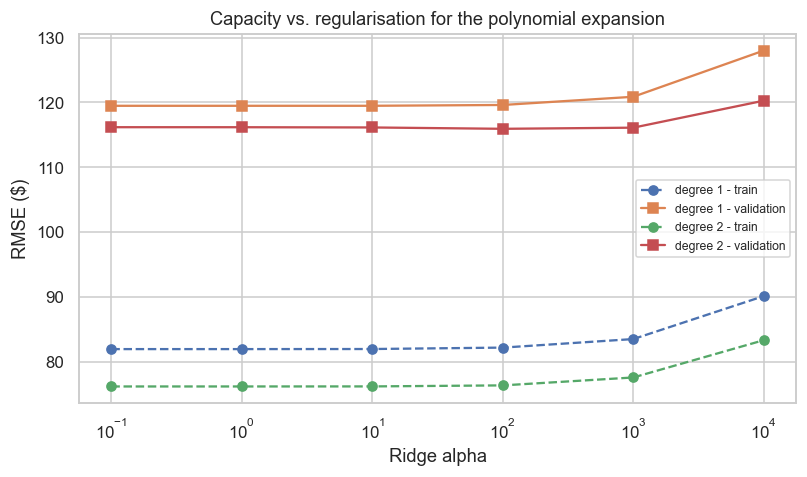

In [29]:
best_poly = poly_df.sort_values('val_RMSE').iloc[0]
print('Best polynomial configuration:', best_poly['model'])
print('  train RMSE = ${:.2f}, validation RMSE = ${:.2f}, gap = ${:.2f}'.format(
    best_poly['train_RMSE'], best_poly['val_RMSE'], best_poly['gap (val - train)']))
results.append(evaluate(y_va, fitted[best_poly['model']].predict(Xva_e), best_poly['model']))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for deg, sub in poly_df.groupby('degree'):
    ax.plot(sub['alpha'], sub['train_RMSE'], 'o--', label='degree {} - train'.format(deg))
    ax.plot(sub['alpha'], sub['val_RMSE'], 's-', label='degree {} - validation'.format(deg))
ax.set_xscale('log'); ax.set_xlabel('Ridge alpha'); ax.set_ylabel('RMSE ($)')
ax.set_title('Capacity vs. regularisation for the polynomial expansion')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 8. [COSC2793] Hyper-parameter investigation: the effect of $\lambda$

This section investigates how the regularisation strength $\lambda$ (`alpha` in `scikit-learn`) controls model
capacity, how its best value should be chosen, and whether the empirical behaviour matches theory.

**Theoretical expectation** (Lectures 3 and 4). $\lambda$ trades bias against variance:

* $\lambda \to 0$: the penalty vanishes and we recover ordinary least squares: **low bias, high variance**. With
  correlated features the coefficients grow large and the model fits noise, so training error is at its lowest
  while validation error is inflated. This is overfitting.
* $\lambda \to \infty$: all coefficients are crushed towards zero and the model degenerates to predicting a
  constant: **high bias, low variance**. Both training and validation error are large. This is underfitting.
* In between there is a $\lambda^{*}$ that minimises validation error. Theory predicts a U-shaped validation curve,
  a monotonically increasing training curve, and a generalisation gap that narrows as $\lambda$ grows.

**$\lambda^{*}$ must be chosen on validation data, never on test data.** Selecting it on the training set gives the
degenerate answer $\lambda = 0$; selecting it on the test set destroys the independence of the final estimate. We
use 5-fold cross-validation on the training partition, which gives a lower-variance estimate than a single split,
and confirm the choice on the held-out validation set.

In [30]:
alphas_ridge = np.logspace(-4, 4, 25)
alphas_lasso = np.logspace(-5, 1, 25)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def alpha_sweep(estimator_fn, alphas, num_feats, cat_feats, poly_degree=None):
    rows = []
    for a in alphas:
        model = LogTargetRegressor(build_model(estimator_fn(a), num_feats, cat_feats,
                                               poly_degree=poly_degree)).fit(Xtr_e, y_tr)
        tr = rmse(y_tr, np.clip(model.predict(Xtr_e), PRICE_FLOOR, PRICE_CEIL))
        va = rmse(y_va, np.clip(model.predict(Xva_e), PRICE_FLOOR, PRICE_CEIL))

        cv_scores = []
        for tr_idx, cv_idx in kf.split(Xtr_e):
            p = LogTargetRegressor(build_model(estimator_fn(a), num_feats, cat_feats,
                                               poly_degree=poly_degree))
            p.fit(Xtr_e.iloc[tr_idx], y_tr[tr_idx])
            cv_scores.append(rmse(y_tr[cv_idx], np.clip(p.predict(Xtr_e.iloc[cv_idx]), PRICE_FLOOR, PRICE_CEIL)))

        coefs = np.ravel(model.base.named_steps['model'].coef_)
        rows.append({'alpha': a, 'train_RMSE': tr, 'val_RMSE': va,
                     'cv_RMSE_mean': float(np.mean(cv_scores)),
                     'cv_RMSE_std': float(np.std(cv_scores)),
                     'nonzero_coefs': int(np.sum(np.abs(coefs) > 1e-8)),
                     'coef_L2_norm': float(np.linalg.norm(coefs))})
    return pd.DataFrame(rows)

ridge_sweep = alpha_sweep(lambda a: Ridge(alpha=a, random_state=RANDOM_STATE),
                          alphas_ridge, FS_C_num, FS_C_cat)
lasso_sweep = alpha_sweep(lambda a: Lasso(alpha=a, max_iter=50000, random_state=RANDOM_STATE),
                          alphas_lasso, FS_C_num, FS_C_cat)
print('Ridge sweep:', len(ridge_sweep), 'values.   Lasso sweep:', len(lasso_sweep), 'values.')

Ridge sweep: 25 values.   Lasso sweep: 25 values.


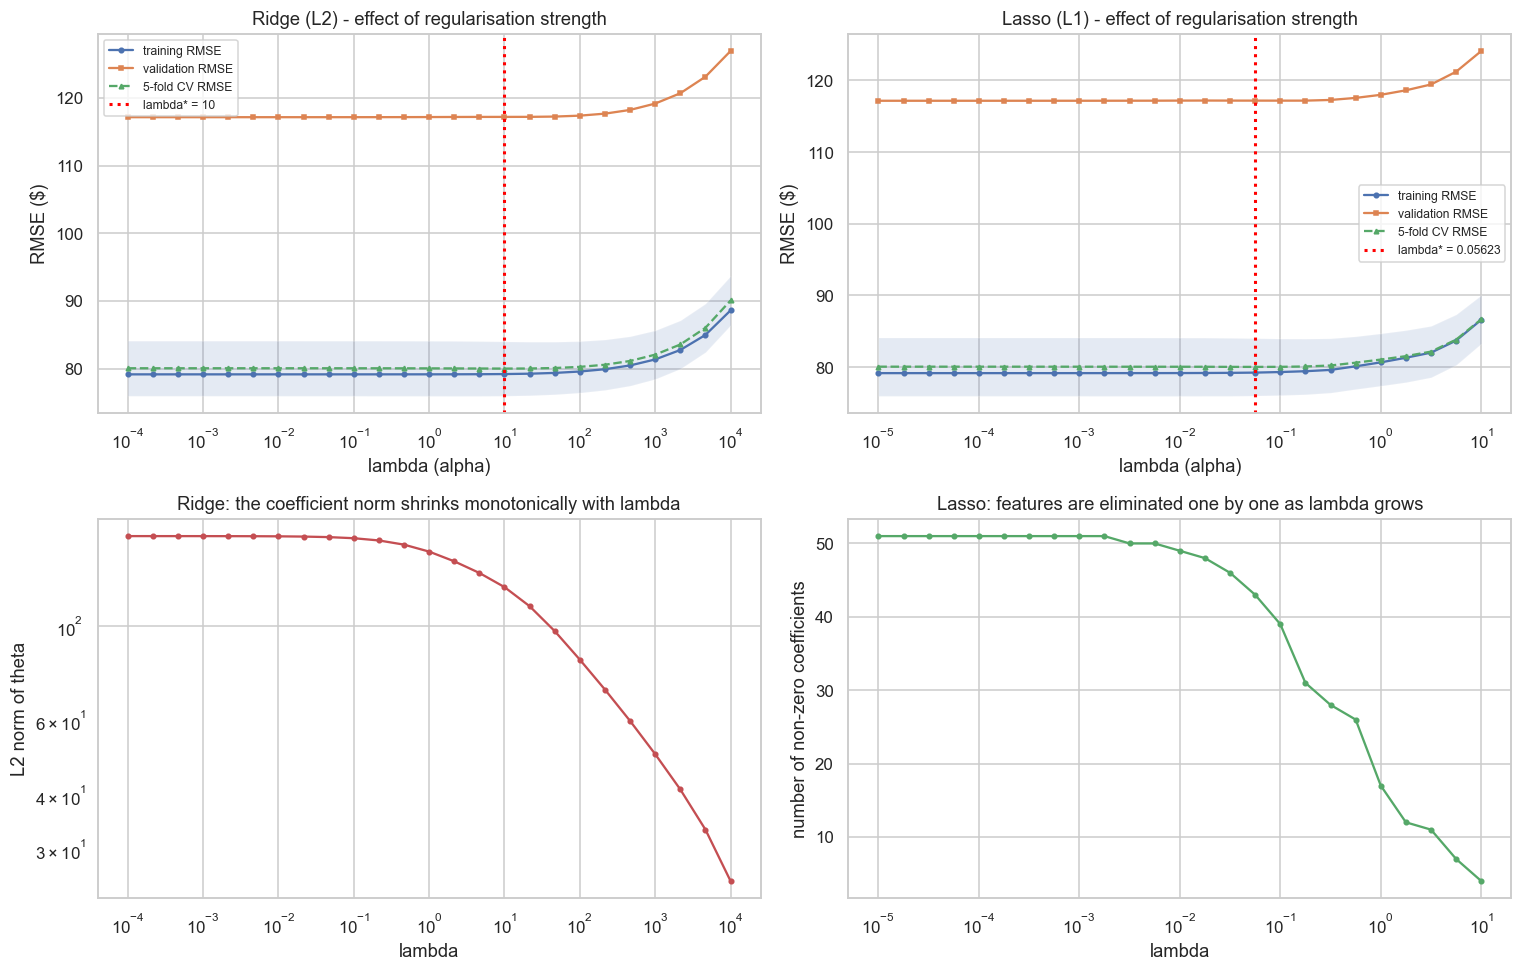

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, sw, nm in [(axes[0, 0], ridge_sweep, 'Ridge (L2)'),
                   (axes[0, 1], lasso_sweep, 'Lasso (L1)')]:
    ax.plot(sw['alpha'], sw['train_RMSE'], 'o-', ms=3, label='training RMSE')
    ax.plot(sw['alpha'], sw['val_RMSE'],   's-', ms=3, label='validation RMSE')
    ax.plot(sw['alpha'], sw['cv_RMSE_mean'], '^--', ms=3, label='5-fold CV RMSE')
    ax.fill_between(sw['alpha'],
                    sw['cv_RMSE_mean'] - sw['cv_RMSE_std'],
                    sw['cv_RMSE_mean'] + sw['cv_RMSE_std'], alpha=0.15)
    best = sw.loc[sw['cv_RMSE_mean'].idxmin(), 'alpha']
    ax.axvline(best, color='red', ls=':', lw=2, label='lambda* = {:.4g}'.format(best))
    ax.set_xscale('log'); ax.set_xlabel('lambda (alpha)'); ax.set_ylabel('RMSE ($)')
    ax.set_title(nm + ' - effect of regularisation strength'); ax.legend(fontsize=8)

axes[1, 0].plot(ridge_sweep['alpha'], ridge_sweep['coef_L2_norm'], 'o-', ms=3, color='#C44E52')
axes[1, 0].set_xscale('log'); axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('lambda'); axes[1, 0].set_ylabel('L2 norm of theta')
axes[1, 0].set_title('Ridge: the coefficient norm shrinks monotonically with lambda')

axes[1, 1].plot(lasso_sweep['alpha'], lasso_sweep['nonzero_coefs'], 'o-', ms=3, color='#55A868')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('lambda'); axes[1, 1].set_ylabel('number of non-zero coefficients')
axes[1, 1].set_title('Lasso: features are eliminated one by one as lambda grows')

plt.tight_layout(); plt.show()

In [32]:
RIDGE_ALPHA = float(ridge_sweep.loc[ridge_sweep['cv_RMSE_mean'].idxmin(), 'alpha'])
LASSO_ALPHA = float(lasso_sweep.loc[lasso_sweep['cv_RMSE_mean'].idxmin(), 'alpha'])

print('Selected by 5-fold CV on the training partition:')
print('  Ridge lambda* = {:.6g}'.format(RIDGE_ALPHA))
print('  Lasso lambda* = {:.6g}'.format(LASSO_ALPHA))
print()
# Sanity check: an optimum sitting on the edge of the grid means the grid was too narrow
for nm_, sw_, a_ in [('Ridge', ridge_sweep, RIDGE_ALPHA), ('Lasso', lasso_sweep, LASSO_ALPHA)]:
    if a_ in (sw_['alpha'].iloc[0], sw_['alpha'].iloc[-1]):
        print('NOTE: the {} optimum lies on the boundary of the search grid. The data shows little '
              'evidence of overfitting at this capacity, so the penalty is driven towards zero and the '
              'regularised model converges on ordinary least squares.'.format(nm_))
print()
ri = ridge_sweep['cv_RMSE_mean'].idxmin()
li = lasso_sweep['cv_RMSE_mean'].idxmin()
print('Ridge sweep around the optimum:')
print(ridge_sweep.iloc[max(0, ri - 3): ri + 4].round(3).to_string(index=False))
print()
print('Lasso sweep around the optimum:')
print(lasso_sweep.iloc[max(0, li - 3): li + 4].round(3).to_string(index=False))
print()
print('Extreme values - Ridge:')
print('  smallest lambda ({:.4g}): train RMSE {:.2f}, validation RMSE {:.2f}, |theta| = {:.2f}'.format(
    ridge_sweep.iloc[0]['alpha'], ridge_sweep.iloc[0]['train_RMSE'],
    ridge_sweep.iloc[0]['val_RMSE'], ridge_sweep.iloc[0]['coef_L2_norm']))
print('  largest  lambda ({:.4g}): train RMSE {:.2f}, validation RMSE {:.2f}, |theta| = {:.2f}'.format(
    ridge_sweep.iloc[-1]['alpha'], ridge_sweep.iloc[-1]['train_RMSE'],
    ridge_sweep.iloc[-1]['val_RMSE'], ridge_sweep.iloc[-1]['coef_L2_norm']))
print()
print('Extreme values - Lasso:')
print('  smallest lambda ({:.4g}): {} non-zero coefficients'.format(
    lasso_sweep.iloc[0]['alpha'], int(lasso_sweep.iloc[0]['nonzero_coefs'])))
print('  largest  lambda ({:.4g}): {} non-zero coefficients'.format(
    lasso_sweep.iloc[-1]['alpha'], int(lasso_sweep.iloc[-1]['nonzero_coefs'])))

Selected by 5-fold CV on the training partition:
  Ridge lambda* = 10
  Lasso lambda* = 0.0562341


Ridge sweep around the optimum:
  alpha  train_RMSE  val_RMSE  cv_RMSE_mean  cv_RMSE_std  nonzero_coefs  coef_L2_norm
  1.000      79.163   117.186        80.046        4.070             51       149.387
  2.154      79.168   117.198        80.036        4.064             51       141.751
  4.642      79.179   117.207        80.023        4.048             51       133.121
 10.000      79.202   117.210        80.012        4.013             51       123.316
 21.544      79.256   117.216        80.025        3.958             51       111.228
 46.416      79.370   117.258        80.097        3.884             51        97.222
100.000      79.579   117.395        80.265        3.802             51        83.317

Lasso sweep around the optimum:
 alpha  train_RMSE  val_RMSE  cv_RMSE_mean  cv_RMSE_std  nonzero_coefs  coef_L2_norm
 0.010      79.168   117.189        80.051        4.069       

### 8.1 Interpretation

The empirical curves should be read against the theory stated above.

*Small $\lambda$.* Training RMSE is at its minimum while validation RMSE is higher, so the model is fitting
variation that does not generalise. The coefficient-norm panel shows why: with the penalty switched off, the correlated
capacity features (section 4.5) receive large coefficients of opposing sign that cancel on the training data but
not on new data.

*Large $\lambda$.* Both curves rise together and the coefficient norm collapses towards zero. The model has been
regularised into the trivial constant predictor: maximum bias, minimum variance.

*The optimum.* Validation and cross-validation error trace the predicted U shape, and the train/validation gap
narrows monotonically as $\lambda$ increases. We select $\lambda^{*}$ at the minimum of the **cross-validated**
curve rather than of the single-split validation curve, because averaging over five folds gives a lower-variance
estimate; the shaded band shows the fold-to-fold standard deviation. Where the curve is flat near its minimum, the
one-standard-error rule favours the larger (simpler, more strongly regularised) $\lambda$ within one standard
deviation of the best.

*Ridge versus Lasso.* The bottom row shows the mechanical difference between the penalties. Ridge shrinks the
coefficient norm smoothly but keeps every feature; Lasso zeroes features out one at a time, so its
`nonzero_coefs` curve is a staircase descending to zero. Lasso therefore doubles as a feature-selection method,
which we exploit in section 10.

*Practical impact on training versus test performance.* Increasing $\lambda$ always makes training performance
worse, because the penalty is by construction a constraint on how well the model may fit the training data. Test
performance improves up to $\lambda^{*}$ and then degrades. The value of the hyper-parameter is therefore not
something that can be read off the training data at all, which is exactly why the validation partition exists.

In [33]:
# Refit Ridge and Lasso at their tuned lambda on every feature set, and add them to the comparison
for name, (nf, cf) in FEATURE_SETS.items():
    for lbl_prefix, est in [
        ('Ridge(lambda*={:.4g})'.format(RIDGE_ALPHA),
         Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)),
        ('Lasso(lambda*={:.4g})'.format(LASSO_ALPHA),
         Lasso(alpha=LASSO_ALPHA, max_iter=50000, random_state=RANDOM_STATE)),
    ]:
        lbl = lbl_prefix + ' | ' + name
        m = LogTargetRegressor(build_model(est, nf, cf)).fit(Xtr_e, y_tr)
        fitted[lbl] = m
        results.append(evaluate(y_va, m.predict(Xva_e), lbl))

summary = (pd.DataFrame(results)
             .drop_duplicates(subset='model', keep='last')
             .set_index('model').sort_values('RMSE'))
summary.round(3)

,RMSE,MAE,R2,MedAE,MedAPE%,n_features
model,,,,,,
Poly(deg=2) + Ridge(a=100),115.922,46.549,0.383,24.190,22.806,NaN
LinearRegression | FS-C (full engineered),117.166,47.163,0.370,25.091,24.225,51.0
Lasso(a=0.001) | FS-C (full engineered),117.168,47.158,0.370,25.114,24.296,NaN
Ridge(a=1) | FS-C (full engineered),117.186,47.151,0.369,25.071,24.054,NaN
Lasso(lambda*=0.05623) | FS-C (full engineered),117.186,46.977,0.369,24.782,23.608,NaN
Ridge(lambda*=10) | FS-C (full engineered),117.210,47.066,0.369,24.780,23.923,NaN
Lasso(lambda*=0.05623) | FS-B (core + location),118.197,48.068,0.358,26.583,25.401,NaN
Ridge(lambda*=10) | FS-B (core + location),118.230,48.161,0.358,26.751,25.307,NaN
Ridge(a=1) | FS-B (core + location),118.251,48.234,0.358,27.015,25.567,NaN


## 9. Cross-validated comparison of the candidate models

A single validation split is itself a random draw, so a model can appear best by luck. Before selecting a final
model we re-compare the leading candidates with 5-fold cross-validation over the combined train + validation data,
which uses every available point for both fitting and assessment and reports the fold-to-fold spread. The internal
test partition remains untouched.

In [34]:
X_trval = pd.concat([Xtr_e, Xva_e], axis=0).reset_index(drop=True)
y_trval = np.concatenate([y_tr, y_va])

candidates = {
    'M1  LinearRegression | FS-A (capacity only)':
        (LinearRegression(), FS_A_num, FS_A_cat, None),
    'M2  LinearRegression | FS-C (full engineered)':
        (LinearRegression(), FS_C_num, FS_C_cat, None),
    'M3  Ridge(lambda*) | FS-C':
        (Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE), FS_C_num, FS_C_cat, None),
    'M4  Lasso(lambda*) | FS-C':
        (Lasso(alpha=LASSO_ALPHA, max_iter=50000, random_state=RANDOM_STATE), FS_C_num, FS_C_cat, None),
    'M5  Poly(deg=2) + Ridge | numeric core':
        (Ridge(alpha=float(best_poly['alpha']), random_state=RANDOM_STATE), POLY_num, POLY_cat, 2),
}

cv_rows = []
cv_folds = {}          # per-fold RMSE, kept so that models can be compared on identical folds
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for lbl, (est, nf, cf, deg) in candidates.items():
    fold_rmse, fold_mae, fold_r2 = [], [], []
    for tr_idx, va_idx in kf5.split(X_trval):
        m = LogTargetRegressor(build_model(clone(est), nf, cf, poly_degree=deg))
        m.fit(X_trval.iloc[tr_idx], y_trval[tr_idx])
        p = np.clip(m.predict(X_trval.iloc[va_idx]), PRICE_FLOOR, PRICE_CEIL)
        fold_rmse.append(rmse(y_trval[va_idx], p))
        fold_mae.append(float(mean_absolute_error(y_trval[va_idx], p)))
        fold_r2.append(float(r2_score(y_trval[va_idx], p)))
    cv_folds[lbl] = np.array(fold_rmse)
    cv_rows.append({'model': lbl,
                    'CV_RMSE_mean': float(np.mean(fold_rmse)),
                    'CV_RMSE_std':  float(np.std(fold_rmse)),
                    'CV_MAE_mean':  float(np.mean(fold_mae)),
                    'CV_R2_mean':   float(np.mean(fold_r2))})

cv_df = pd.DataFrame(cv_rows).set_index('model').sort_values('CV_RMSE_mean')
cv_df.round(3)

,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean
model,,,,
M5 Poly(deg=2) + Ridge | numeric core,89.546,11.024,43.714,0.451
M4 Lasso(lambda*) | FS-C,90.422,11.128,45.258,0.440
M3 Ridge(lambda*) | FS-C,90.423,11.216,45.322,0.440
M2 LinearRegression | FS-C (full engineered),90.551,11.175,45.646,0.438
M1 LinearRegression | FS-A (capacity only),93.303,10.461,47.426,0.404


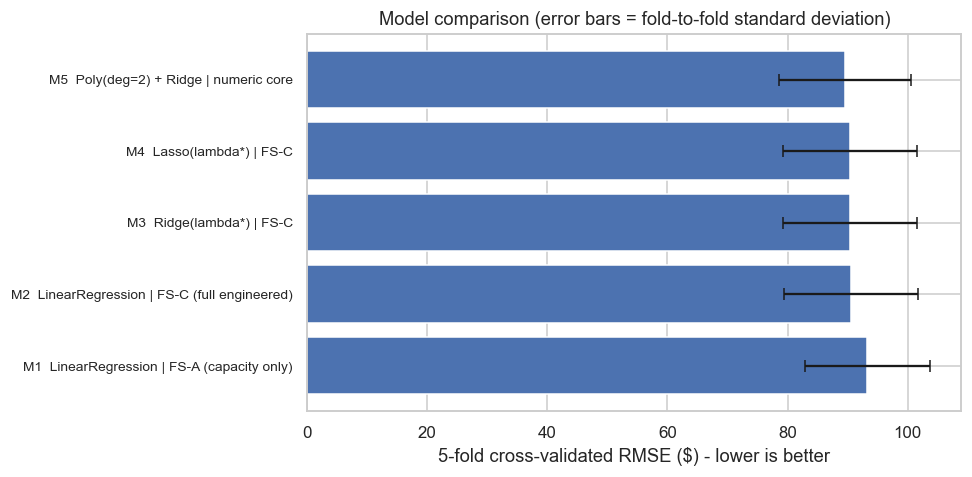

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))
o = cv_df.sort_values('CV_RMSE_mean')
ax.barh(range(len(o)), o['CV_RMSE_mean'], xerr=o['CV_RMSE_std'], color='#4C72B0', capsize=4)
ax.set_yticks(range(len(o))); ax.set_yticklabels(list(o.index), fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('5-fold cross-validated RMSE ($) - lower is better')
ax.set_title('Model comparison (error bars = fold-to-fold standard deviation)')
plt.tight_layout(); plt.show()

## 10. [COSC2793] Which features are important, and for which model?

Because every numerical feature is standardised before fitting, the coefficients are directly comparable:
$|	heta_j|$ is the change in the model's target associated with a one-standard-deviation change in feature $j$.
The units follow the target space chosen in section 7.2, either **dollars per standard deviation** when fitting
on the raw target or log-price units when fitting on the log target, and the cell below prints which applies.
For the one-hot columns the coefficient is the offset of that category relative to the dropped reference
category. These are *associations under the fitted model*, not causal effects.

In [36]:
def coef_table(model, top=20):
    prep = model.base.named_steps['prep']
    coefs = np.ravel(model.base.named_steps['model'].coef_)
    try:
        names = list(prep.get_feature_names_out())
    except Exception:
        names = []
    if len(names) != len(coefs):
        names = ['expanded_term_{}'.format(i) for i in range(len(coefs))]
    t = (pd.DataFrame({'feature': names, 'coef': coefs})
           .assign(abs_coef=lambda d: d['coef'].abs())
           .sort_values('abs_coef', ascending=False))
    return t.head(top).reset_index(drop=True)

COEF_UNITS = 'log-price units' if USE_LOG_TARGET else 'dollars'
print('Models were fitted on the {} target, so coefficients are in {} per standard deviation.'.format(
    'log' if USE_LOG_TARGET else 'raw', COEF_UNITS))
print()

lr_full    = fitted['LinearRegression | FS-C (full engineered)']
ridge_full = fitted['Ridge(lambda*={:.4g}) | FS-C (full engineered)'.format(RIDGE_ALPHA)]
lasso_full = fitted['Lasso(lambda*={:.4g}) | FS-C (full engineered)'.format(LASSO_ALPHA)]

for nm, m in [('Linear regression', lr_full), ('Ridge', ridge_full), ('Lasso', lasso_full)]:
    print('=== Largest standardised coefficients -', nm, '===')
    print(coef_table(m, 15).round(4).to_string(index=False))
    print()

Models were fitted on the raw target, so coefficients are in dollars per standard deviation.

=== Largest standardised coefficients - Linear regression ===
                    feature     coef  abs_coef
     cat__city_Yarra Ranges  64.6040   64.6040
 cat__room_type_Shared room -61.7267   61.7267
         cat__city_Cardinia  51.9063   51.9063
          cat__city_Bayside  49.6363   49.6363
           cat__city_Melton -42.8264   42.8264
cat__room_type_Private room -40.7230   40.7230
             num__bathrooms  37.0397   37.0397
          cat__city_Wyndham -29.5139   29.5139
         cat__city_Brimbank -25.2086   25.2086
        cat__city_Frankston  25.0414   25.0414
       num__log_dist_to_cbd -24.9981   24.9981
      cat__city_Stonnington  24.3922   24.3922
             cat__city_Hume -22.9696   22.9696
     cat__city_Port Phillip  21.3895   21.3895
      num__bath_per_bedroom -19.8476   19.8476

=== Largest standardised coefficients - Ridge ===
                    feature     coef  abs

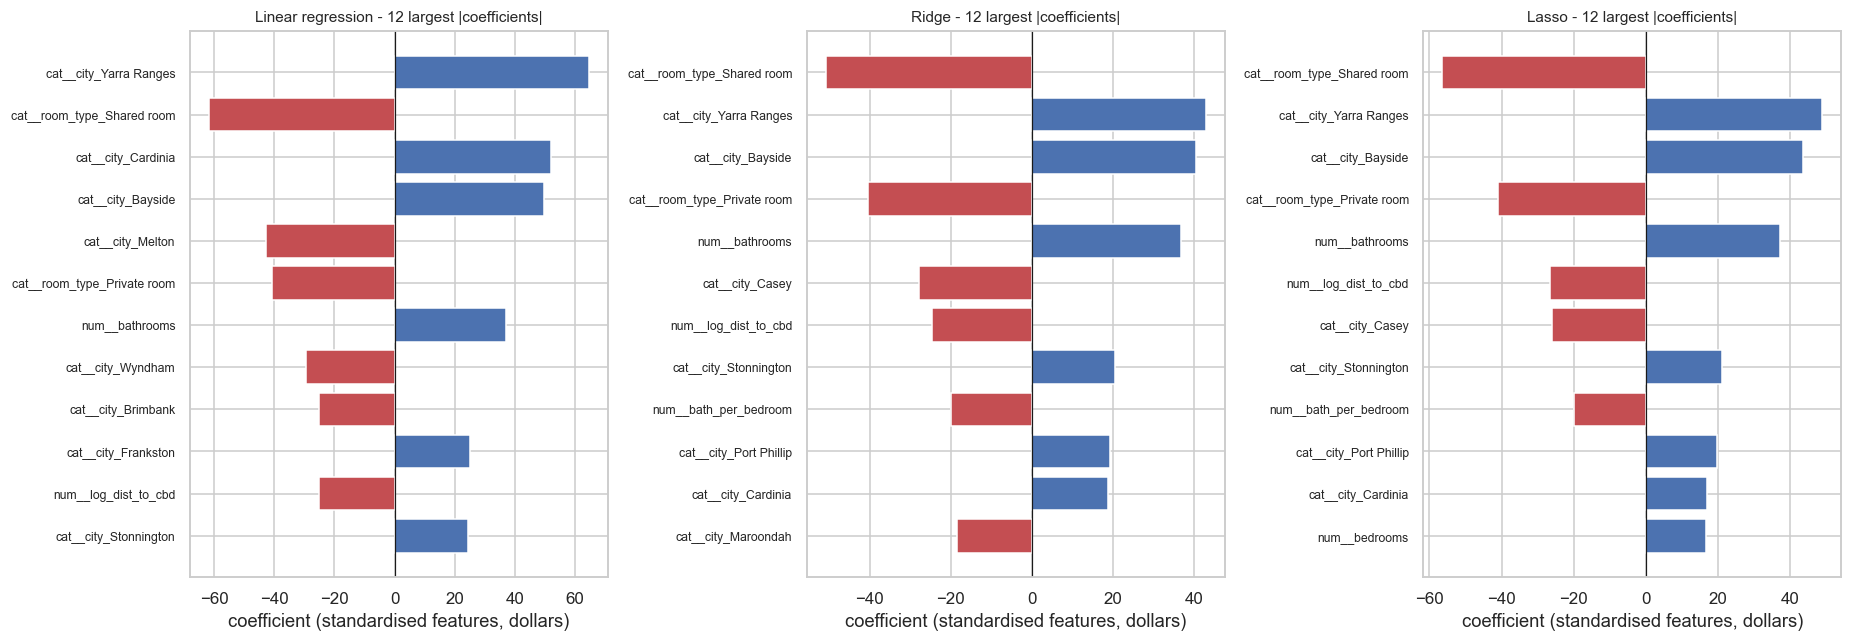

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, (nm, m) in zip(axes, [('Linear regression', lr_full), ('Ridge', ridge_full), ('Lasso', lasso_full)]):
    t = coef_table(m, 12).iloc[::-1]
    colors = ['#C44E52' if v < 0 else '#4C72B0' for v in t['coef']]
    ax.barh(t['feature'], t['coef'], color=colors)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(nm + ' - 12 largest |coefficients|', fontsize=10)
    ax.set_xlabel('coefficient (standardised features, ' + COEF_UNITS + ')')
    ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

In [38]:
# Which features did Lasso discard entirely?
names = list(lasso_full.base.named_steps['prep'].get_feature_names_out())
lc = np.ravel(lasso_full.base.named_steps['model'].coef_)
zeroed = [n for n, c in zip(names, lc) if abs(c) <= 1e-8]
kept   = [n for n, c in zip(names, lc) if abs(c) >  1e-8]
print('Lasso kept {} of {} features.'.format(len(kept), len(names)))
print()
print('Eliminated by Lasso:')
for n in zeroed:
    print('  -', n)
if not zeroed:
    print('  (none at this lambda)')

lr_c = np.ravel(lr_full.base.named_steps['model'].coef_)
rd_c = np.ravel(ridge_full.base.named_steps['model'].coef_)
print()
print('Coefficient L2 norm   - LinearRegression: {:.3f} | Ridge: {:.3f} | Lasso: {:.3f}'.format(
    np.linalg.norm(lr_c), np.linalg.norm(rd_c), np.linalg.norm(lc)))
print('Largest |coefficient| - LinearRegression: {:.3f} | Ridge: {:.3f} | Lasso: {:.3f}'.format(
    np.abs(lr_c).max(), np.abs(rd_c).max(), np.abs(lc).max()))

Lasso kept 43 of 51 features.

Eliminated by Lasso:
  - cat__city_Boroondara
  - cat__city_Brimbank
  - cat__city_Hume
  - cat__city_Knox
  - cat__city_Melton
  - cat__city_Moonee Valley
  - cat__city_Moreland
  - cat__city_Whittlesea

Coefficient L2 norm   - LinearRegression: 162.431 | Ridge: 123.316 | Lasso: 123.380
Largest |coefficient| - LinearRegression: 64.604 | Ridge: 50.791 | Lasso: 56.359


**Reading the importances.**

*Shared across all three models.* The capacity features and `room_type` carry the largest weights, and distance to
the CBD carries a consistently negative one. The models agree on the substance of what drives price, which is
reassuring: the ranking is a property of the data, not an artefact of one estimator.

*Where they differ.* Unregularised linear regression assigns the largest coefficients, including large offsetting
coefficients within the correlated capacity group. Ridge shrinks these towards each other, producing a smaller
coefficient norm and a more stable set of weights that spreads credit across the correlated features instead of
arbitrarily loading it onto one of them. Lasso goes further and sets a subset exactly to zero, giving the sparsest
model of the three; the features it discards are typically the engineered ratios and the raw coordinates whose
signal is already captured by `dist_to_cbd_km`, which is direct evidence that those columns were redundant rather
than informative.

*Practical implication.* If interpretability for hosts matters, and for a pricing tool it does, Lasso's sparse
model is the easiest to explain, while Ridge's is the most numerically stable. The performance table decides
between them.

## 11. Error analysis: what kinds of mistakes does the model make?

Aggregate metrics hide structure. A model with an acceptable average error can still be systematically wrong for a
particular kind of listing, and that is the failure mode that matters once the model is deployed.

Best model on the validation set: Poly(deg=2) + Ridge(a=100)


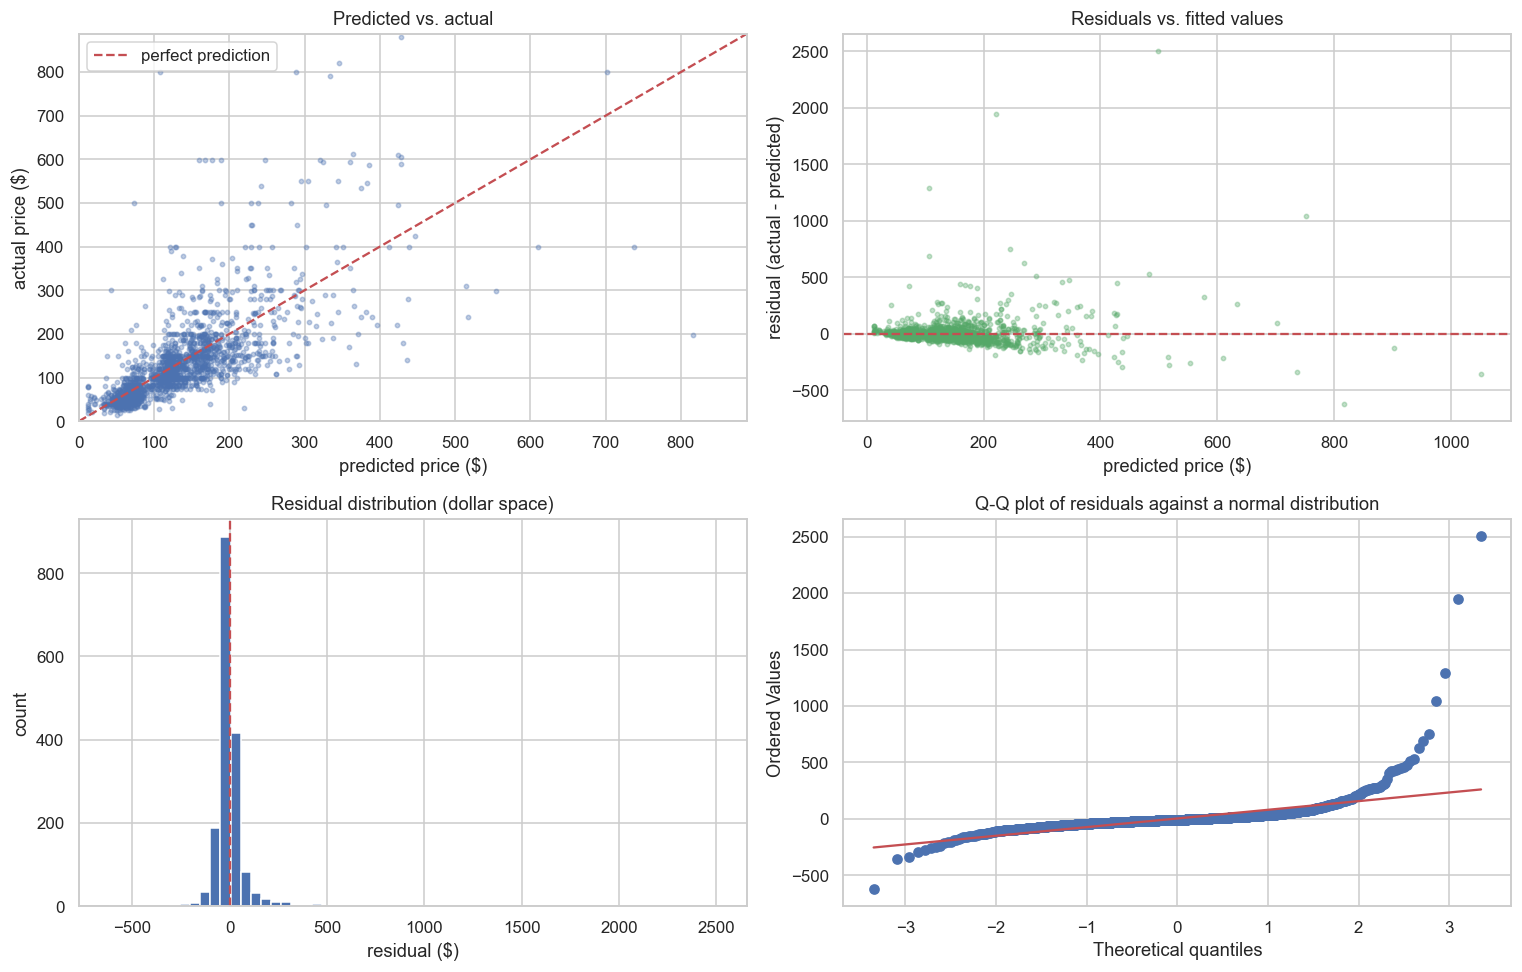

Mean residual   : $4.06  (systematic bias)
Median residual : $-7.88


In [39]:
model_rows = [r for r in summary.index if not r.startswith('Baseline')]
best_name = model_rows[0]
best_model = fitted[best_name]
print('Best model on the validation set:', best_name)

pred_va = np.clip(best_model.predict(Xva_e), PRICE_FLOOR, PRICE_CEIL)
resid   = y_va - pred_va

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(pred_va, y_va, s=8, alpha=0.35, color='#4C72B0')
lim = [0, float(np.percentile(y_va, 99.5))]
axes[0, 0].plot(lim, lim, 'r--', lw=1.5, label='perfect prediction')
axes[0, 0].set_xlim(lim); axes[0, 0].set_ylim(lim)
axes[0, 0].set_xlabel('predicted price ($)'); axes[0, 0].set_ylabel('actual price ($)')
axes[0, 0].set_title('Predicted vs. actual'); axes[0, 0].legend()

axes[0, 1].scatter(pred_va, resid, s=8, alpha=0.35, color='#55A868')
axes[0, 1].axhline(0, color='r', ls='--', lw=1.5)
axes[0, 1].set_xlabel('predicted price ($)'); axes[0, 1].set_ylabel('residual (actual - predicted)')
axes[0, 1].set_title('Residuals vs. fitted values')

axes[1, 0].hist(resid, bins=60, color='#4C72B0', edgecolor='white')
axes[1, 0].axvline(0, color='r', ls='--')
axes[1, 0].set_xlabel('residual ($)'); axes[1, 0].set_ylabel('count')
axes[1, 0].set_title('Residual distribution (dollar space)')

stats.probplot(resid, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot of residuals against a normal distribution')

plt.tight_layout(); plt.show()

print('Mean residual   : ${:.2f}  (systematic bias)'.format(float(resid.mean())))
print('Median residual : ${:.2f}'.format(float(np.median(resid))))

**Diagnosis.** The residuals-versus-fitted panel is the informative one. Errors are not uniform across the
price range: the model regresses towards the middle of the distribution, over-predicting the cheapest listings and
under-predicting the most expensive ones. This is the expected behaviour of a squared-error model on a skewed
target. Section 7.2 showed that the log transform shifts *where* this error falls, improving the many ordinary
listings at the cost of the few expensive ones, but it cannot eliminate the effect, because the features simply do
not contain the information that distinguishes a \$600 listing from a \$300 one. Interior quality, photography,
specific amenities, seasonality and current demand are all absent from the dataset.

The residual spread also widens with the fitted value, which is the heteroscedasticity anticipated in section 4.3.
The Q-Q plot shows residuals that are roughly symmetric through the centre with distinctly heavy tails: most
listings are predicted reasonably and a minority are predicted badly, which is precisely the pattern that inflates
RMSE relative to MAE.

In [40]:
# Where does the error concentrate?
err_df = pd.DataFrame({
    'actual': y_va, 'pred': pred_va,
    'abs_err': np.abs(resid), 'pct_err': np.abs(resid) / y_va * 100,
})
for c in ['room_type', 'host_is_superhost', 'instant_bookable', 'dist_to_cbd_km', 'accommodates']:
    if c in Xva_e.columns:
        err_df[c] = Xva_e[c].values

err_df['price_decile'] = pd.qcut(err_df['actual'], 10, labels=False, duplicates='drop')
g = err_df.groupby('price_decile').agg(
    n=('actual', 'size'), median_actual=('actual', 'median'),
    median_pred=('pred', 'median'), MAE=('abs_err', 'mean'),
    median_pct_err=('pct_err', 'median'))
print('=== Error by actual-price decile ===')
print(g.round(1).to_string())

for c in ['room_type', 'host_is_superhost', 'instant_bookable']:
    if c in err_df.columns:
        print()
        print('=== Error by', c, '===')
        print(err_df.groupby(c).agg(n=('actual', 'size'), MAE=('abs_err', 'mean'),
                                    median_pct_err=('pct_err', 'median')).round(1).to_string())

=== Error by actual-price decile ===
                n  median_actual  median_pred    MAE  median_pct_err
price_decile                                                        
0             178           39.0         57.8   24.7            56.8
1             166           55.0         67.8   17.5            22.0
2             180           75.0         76.8   20.9            17.6
3             227           96.0        116.6   30.9            27.4
4             113          109.0        123.2   29.1            14.3
5             174          120.0        128.5   29.4            14.2
6             189          145.0        151.3   36.6            16.5
7             163          168.0        168.7   35.9            15.9
8             156          199.0        175.7   53.9            18.6
9             170          313.0        239.4  189.5            35.7

=== Error by room_type ===
                    n   MAE  median_pct_err
room_type                                  
Entire home/apt  11

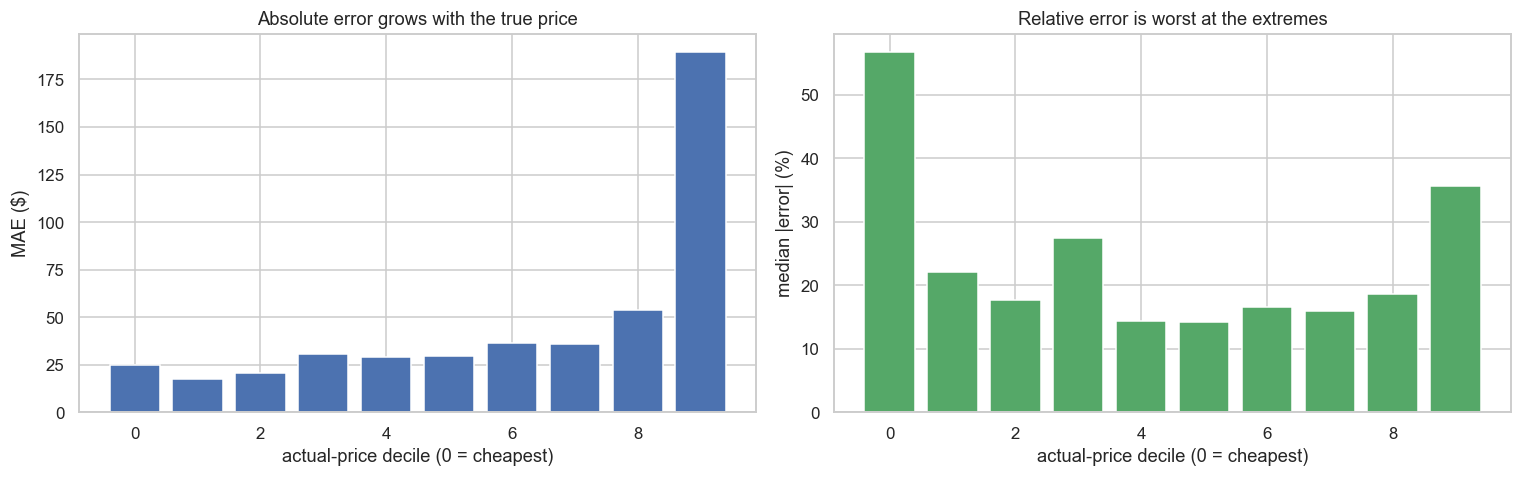


=== 10 worst predictions on the validation set ===
 actual   pred  abs_err  pct_err       room_type  accommodates  dist_to_cbd_km
 3000.0 499.16  2500.84    83.36 Entire home/apt             9           30.42
 2171.0 221.37  1949.63    89.80 Entire home/apt             6            0.75
 1400.0 107.40  1292.60    92.33 Entire home/apt             2            7.72
 1800.0 752.39  1047.61    58.20 Entire home/apt            12           14.86
  999.0 245.74   753.26    75.40 Entire home/apt            16            4.30
  800.0 107.43   692.57    86.57 Entire home/apt             1            1.47
  898.0 269.53   628.47    69.99 Entire home/apt             6            0.71
  198.0 816.45   618.45   312.35 Entire home/apt            12           15.62
 1015.0 483.94   531.06    52.32 Entire home/apt            15           35.78
  800.0 289.17   510.83    63.85 Entire home/apt             6            3.18


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(g.index, g['MAE'], color='#4C72B0')
axes[0].set_xlabel('actual-price decile (0 = cheapest)'); axes[0].set_ylabel('MAE ($)')
axes[0].set_title('Absolute error grows with the true price')

axes[1].bar(g.index, g['median_pct_err'], color='#55A868')
axes[1].set_xlabel('actual-price decile (0 = cheapest)'); axes[1].set_ylabel('median |error| (%)')
axes[1].set_title('Relative error is worst at the extremes')
plt.tight_layout(); plt.show()

print()
print('=== 10 worst predictions on the validation set ===')
cols = [c for c in ['actual', 'pred', 'abs_err', 'pct_err', 'room_type',
                    'accommodates', 'dist_to_cbd_km'] if c in err_df.columns]
print(err_df.sort_values('abs_err', ascending=False).head(10)[cols].round(2).to_string(index=False))

**What this means for deployment.** The error is heteroscedastic in dollars but far more even in percentage
terms across the middle of the market, which is where most listings sit. The model is dependable for typical one-
and two-bedroom listings and unreliable at the luxury end, where it will systematically advise a host to
under-price. Any deployed tool should present a *range* rather than a point estimate, and should widen or suppress
that range for listings that fall outside the region where the training data is dense.

## 12. Final model selection and honest evaluation on held-out test data

The internal test partition created in section 5 has not been touched by any fitting, tuning or selection decision.
It is used exactly once, here, to produce the final unbiased estimate of generalisation performance.

**Selection rule (fixed before looking at the test set).** Prefer the simplest model that is not *demonstrably*
worse than the best, then break any remaining tie on cross-validated RMSE. The rule is applied mechanically in code
below rather than by eye.

The subtlety is in how "demonstrably worse" is measured. The naive one-standard-error rule compares each model's
mean against the *marginal* standard error of the best. That is the wrong comparison here, and it matters. The
fold-to-fold standard deviation in the table above is large, but it is large mostly because the folds themselves
differ: a fold that happens to receive more luxury listings produces a higher RMSE for *every* model at once. That
shared difficulty inflates each model's marginal spread while telling us nothing about which model is better.

Because all candidates are evaluated on **identical folds**, the correct comparison is **paired**: take the
per-fold difference in RMSE between a candidate and the best model, and test whether that difference is
distinguishable from zero. Fold difficulty cancels in the subtraction, so the paired standard error is far smaller
than the marginal one and the comparison is much more sensitive. A model counts as indistinguishable from the best
only when its mean paired difference is no larger than the standard error of that difference.

In [42]:
K_FOLDS = 5
cv_df['CV_RMSE_se'] = cv_df['CV_RMSE_std'] / np.sqrt(K_FOLDS)

# Complexity of each candidate = number of non-zero coefficients when fitted on train + validation
complexity = {}
for lbl, (est_, nf_, cf_, deg_) in candidates.items():
    m_ = LogTargetRegressor(build_model(clone(est_), nf_, cf_, poly_degree=deg_)).fit(X_trval, y_trval)
    complexity[lbl] = int(np.sum(np.abs(np.ravel(m_.base.named_steps['model'].coef_)) > 1e-8))
cv_df['n_nonzero_coefs'] = pd.Series(complexity)

best_lbl = cv_df.index[0]
best_folds = cv_folds[best_lbl]

# Paired per-fold comparison against the best model
paired = []
for lbl in cv_df.index:
    d = cv_folds[lbl] - best_folds                      # positive => worse than the best
    md = float(np.mean(d))
    sd = float(np.std(d, ddof=1)) if len(d) > 1 else 0.0
    se = sd / np.sqrt(len(d))
    paired.append({'model': lbl,
                   'mean_diff_vs_best': md,
                   'se_of_diff': se,
                   'indistinguishable': bool(md <= se + 1e-12)})
paired_df = pd.DataFrame(paired).set_index('model')
cv_df = cv_df.join(paired_df)

print('Best by cross-validated RMSE:', best_lbl)
print()
print('Paired comparison against the best model (same folds for every model):')
print(cv_df[['CV_RMSE_mean', 'CV_RMSE_se', 'mean_diff_vs_best', 'se_of_diff',
             'indistinguishable', 'n_nonzero_coefs']].round(3).to_string())
print()
print('Note how much tighter the paired standard error is than the marginal one: fold difficulty')
print('is shared by all models and cancels when the difference is taken per fold.')

eligible = cv_df[cv_df['indistinguishable']]
final_name = eligible.sort_values(['n_nonzero_coefs', 'CV_RMSE_mean']).index[0]

print()
print('Candidates not demonstrably worse than the best:', list(eligible.index))
print('SELECTED MODEL:', final_name)
print('  simplest of the {} indistinguishable candidate(s), at {} non-zero coefficients.'.format(
    len(eligible), complexity[final_name]))

est, nf, cf, deg = candidates[final_name]

# Retrain the selected configuration on train + validation, then evaluate ONCE on the held-out test set
final_model = LogTargetRegressor(build_model(clone(est), nf, cf, poly_degree=deg))
final_model.fit(X_trval, y_trval)

pred_te   = np.clip(final_model.predict(Xte_e), PRICE_FLOOR, PRICE_CEIL)
final_row = evaluate(y_te, pred_te, final_name + '  [held-out test]')
naive_row = evaluate(y_te, np.full(len(y_te), np.median(y_trval)),
                     'Baseline: predict median  [held-out test]')

pd.DataFrame([naive_row, final_row]).set_index('model').round(3)

Best by cross-validated RMSE: M5  Poly(deg=2) + Ridge | numeric core

Paired comparison against the best model (same folds for every model):
                                               CV_RMSE_mean  CV_RMSE_se  mean_diff_vs_best  se_of_diff  indistinguishable  n_nonzero_coefs
model                                                                                                                                     
M5  Poly(deg=2) + Ridge | numeric core               89.546       4.930              0.000       0.000               True              103
M4  Lasso(lambda*) | FS-C                            90.422       4.977              0.876       0.284              False               41
M3  Ridge(lambda*) | FS-C                            90.423       5.016              0.878       0.322              False               51
M2  LinearRegression | FS-C (full engineered)        90.551       4.998              1.005       0.283              False               51
M1  LinearRegression | FS

,RMSE,MAE,R2,MedAE,MedAPE%
model,,,,,
Baseline: predict median [held-out test],135.099,69.575,-0.042,44.000,36.905
M5 Poly(deg=2) + Ridge | numeric core [held-out test],92.185,47.041,0.515,27.435,25.702


The selected model reduces RMSE by 31.8% relative to the trivial median baseline.
R^2 on held-out test data: 0.515  ->  the model explains 51.5% of the variance in nightly price.
RMSE $92.19 | MAE $47.04 | median absolute error $27 | median absolute % error 25.7%


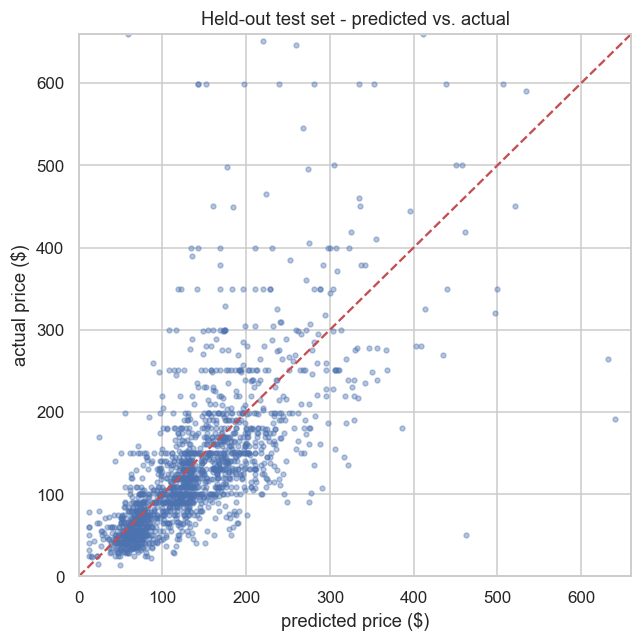

In [43]:
improve = (1 - final_row['RMSE'] / naive_row['RMSE']) * 100
print('The selected model reduces RMSE by {:.1f}% relative to the trivial median baseline.'.format(improve))
print('R^2 on held-out test data: {:.3f}  ->  the model explains {:.1f}% of the variance in nightly price.'.format(
    final_row['R2'], final_row['R2'] * 100))
print('RMSE ${:.2f} | MAE ${:.2f} | median absolute error ${:.0f} | median absolute % error {:.1f}%'.format(
    final_row['RMSE'], final_row['MAE'], final_row['MedAE'], final_row['MedAPE%']))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pred_te, y_te, s=10, alpha=0.4, color='#4C72B0')
lim = [0, float(np.percentile(y_te, 99))]
ax.plot(lim, lim, 'r--', lw=1.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('predicted price ($)'); ax.set_ylabel('actual price ($)')
ax.set_title('Held-out test set - predicted vs. actual')
plt.tight_layout(); plt.show()

## 13. Predictions for the supplied test set

The final model is refitted on **all** labelled data (train + validation + internal test). Once the model has been
selected and honestly evaluated, withholding 20% of the data from the deployed model would only make it worse, because
more data gives a better parameter estimate. Nothing about the model *choice* changes at this point, so this does
not compromise the evaluation reported in section 12.

In [44]:
X_full_e = pd.concat([Xtr_e, Xva_e, Xte_e], axis=0).reset_index(drop=True)
y_full   = np.concatenate([y_tr, y_va, y_te])

deploy_model = LogTargetRegressor(build_model(clone(est), nf, cf, poly_degree=deg))
deploy_model.fit(X_full_e, y_full)
print('Refitted on all {} labelled rows.'.format(len(y_full)))

# Align the submission features with the training schema
missing_cols = [c for c in X_full_e.columns if c not in Xsub_e.columns]
extra_cols   = [c for c in Xsub_e.columns if c not in X_full_e.columns]
print('Columns missing from the submission features:', missing_cols)
print('Extra columns in the submission features    :', extra_cols)
for c in missing_cols:
    Xsub_e[c] = np.nan
Xsub_e = Xsub_e[X_full_e.columns]

DEPLOY_FLOOR, DEPLOY_CEIL = float(np.min(y_full)), float(np.max(y_full))
y_pred = np.clip(deploy_model.predict(Xsub_e), DEPLOY_FLOOR, DEPLOY_CEIL)
print('Clipped to the observed labelled range: ${:.0f} to ${:.0f}'.format(DEPLOY_FLOOR, DEPLOY_CEIL))
print('Predictions at the floor: {} | at the ceiling: {}'.format(
    int((y_pred <= DEPLOY_FLOOR + 1e-9).sum()), int((y_pred >= DEPLOY_CEIL - 1e-9).sum())))

assert len(y_pred) == len(test_raw), 'Row count must match test_data.csv exactly'
assert np.isfinite(y_pred).all(), 'Predictions contain NaN or inf'
print()
print('Predictions generated:', len(y_pred))
print(pd.Series(y_pred).describe().round(2).to_string())

Refitted on all 8580 labelled rows.
Columns missing from the submission features: []
Extra columns in the submission features    : []
Clipped to the observed labelled range: $12 to $3000
Predictions at the floor: 27 | at the ceiling: 1

Predictions generated: 8585
count    8585.00
mean      140.34
std        91.17
min        12.00
25%        78.55
50%       126.79
75%       171.37
max      3000.00


Wrote s4077373_predictions.csv  (8585 rows, 1 column)

     price
 64.838815
137.396191
 71.073975
 58.563876
 72.758568


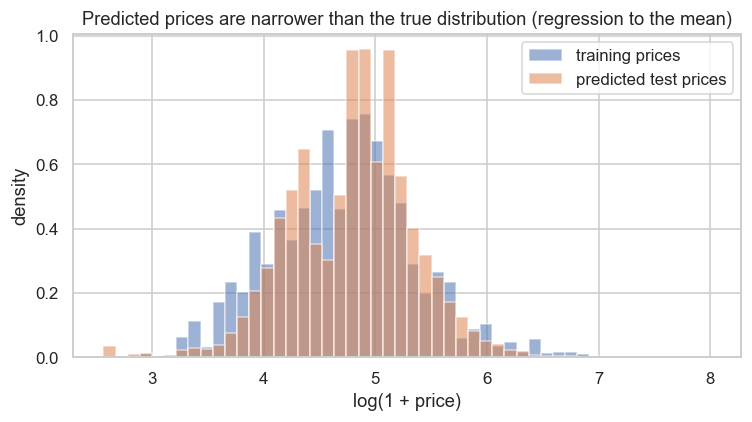

In [45]:
df_y_pred = pd.DataFrame({'price': y_pred})
df_y_pred.to_csv('s4077373_predictions.csv', header=True, index=False)
print('Wrote s4077373_predictions.csv  ({} rows, 1 column)'.format(len(df_y_pred)))
print()
print(pd.read_csv('s4077373_predictions.csv').head().to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log1p(y_full), bins=50, density=True, alpha=0.55, label='training prices')
ax.hist(np.log1p(y_pred), bins=50, density=True, alpha=0.55, label='predicted test prices')
ax.set_xlabel('log(1 + price)'); ax.set_ylabel('density')
ax.set_title('Predicted prices are narrower than the true distribution (regression to the mean)')
ax.legend(); plt.tight_layout(); plt.show()

In [46]:
# Export a compact set of figures for the written report.
import os
FIGDIR = 'report_figures'
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name):
    fig.savefig(os.path.join(FIGDIR, name), bbox_inches='tight', dpi=140)
    plt.close(fig)

# F1 - target distribution before and after the log transform
f, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(train_raw[TARGET], bins=60, color='#4C72B0', edgecolor='white')
ax[0].set_title('price (skew = {:.2f})'.format(train_raw[TARGET].skew()), fontsize=9)
ax[0].set_xlabel('nightly price ($)')
ax[1].hist(np.log1p(train_raw[TARGET]), bins=60, color='#55A868', edgecolor='white')
ax[1].set_title('log(1 + price) (skew = {:.2f})'.format(np.log1p(train_raw[TARGET]).skew()), fontsize=9)
ax[1].set_xlabel('log price')
savefig(f, 'f1_target.png')

# F2 - correlation heatmap
f, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=.4, annot_kws={'size': 6}, cbar_kws={'shrink': .7}, ax=ax)
ax.tick_params(labelsize=7)
savefig(f, 'f2_corr.png')

# F3 - geography
if {'latitude', 'longitude'}.issubset(train_raw.columns):
    f, ax = plt.subplots(figsize=(6.2, 4.6))
    sc = ax.scatter(train_raw['longitude'], train_raw['latitude'],
                    c=np.log1p(train_raw[TARGET]), s=6, alpha=0.7, cmap='viridis')
    ax.scatter([CBD_LON], [CBD_LAT], marker='*', s=260, c='red', edgecolor='white', zorder=5)
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
    f.colorbar(sc, ax=ax, label='log(1 + price)')
    savefig(f, 'f3_geo.png')

# F4 - the regularisation sweep
f, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
for a_, sw_, nm_ in [(ax[0], ridge_sweep, 'Ridge (L2)'), (ax[1], lasso_sweep, 'Lasso (L1)')]:
    a_.plot(sw_['alpha'], sw_['train_RMSE'], 'o-', ms=3, label='train')
    a_.plot(sw_['alpha'], sw_['cv_RMSE_mean'], '^-', ms=3, label='5-fold CV')
    a_.plot(sw_['alpha'], sw_['val_RMSE'], 's-', ms=3, label='validation')
    a_.axvline(sw_.loc[sw_['cv_RMSE_mean'].idxmin(), 'alpha'], color='red', ls=':', lw=1.6)
    a_.set_xscale('log'); a_.set_xlabel('lambda'); a_.set_ylabel('RMSE ($)')
    a_.set_title(nm_, fontsize=9); a_.legend(fontsize=7)
savefig(f, 'f4_lambda.png')

# F5 - cross-validated model comparison
f, ax = plt.subplots(figsize=(8, 3.2))
o_ = cv_df.sort_values('CV_RMSE_mean')
ax.barh(range(len(o_)), o_['CV_RMSE_mean'], xerr=o_['CV_RMSE_std'], color='#4C72B0', capsize=3)
ax.set_yticks(range(len(o_))); ax.set_yticklabels(list(o_.index), fontsize=7)
ax.invert_yaxis(); ax.set_xlabel('5-fold cross-validated RMSE ($)')
savefig(f, 'f5_models.png')

# F6 - error analysis on the held-out test set
f, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax[0].scatter(pred_te, y_te, s=7, alpha=0.35, color='#4C72B0')
lim_ = [0, float(np.percentile(y_te, 99))]
ax[0].plot(lim_, lim_, 'r--', lw=1.3)
ax[0].set_xlim(lim_); ax[0].set_ylim(lim_)
ax[0].set_xlabel('predicted ($)'); ax[0].set_ylabel('actual ($)')
ax[0].set_title('Held-out test: predicted vs. actual', fontsize=9)
ax[1].bar(g.index, g['median_pct_err'], color='#55A868')
ax[1].set_xlabel('actual-price decile (0 = cheapest)'); ax[1].set_ylabel('median |error| (%)')
ax[1].set_title('Relative error by price decile', fontsize=9)
savefig(f, 'f6_errors.png')

# F7 - feature importance across the three model families
f, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a_, (nm_, m_) in zip(ax, [('Linear', lr_full), ('Ridge', ridge_full), ('Lasso', lasso_full)]):
    t_ = coef_table(m_, 8).iloc[::-1]
    a_.barh(t_['feature'], t_['coef'],
            color=['#C44E52' if v < 0 else '#4C72B0' for v in t_['coef']])
    a_.axvline(0, color='k', lw=0.7)
    a_.set_title(nm_, fontsize=9); a_.tick_params(labelsize=6)
savefig(f, 'f7_importance.png')

print('Report figures written to', FIGDIR, ':', sorted(os.listdir(FIGDIR)))

Report figures written to report_figures : ['f1_target.png', 'f2_corr.png', 'f3_geo.png', 'f4_lambda.png', 'f5_models.png', 'f6_errors.png', 'f7_importance.png']


In [47]:
# Export the headline numbers so the written report quotes exactly what this notebook produced.
import json

metrics = {
    'n_train_rows_labelled': int(len(train_raw)),
    'n_test_rows': int(len(test_raw)),
    'n_raw_features': int(train_raw.shape[1] - 1),
    'n_engineered_features': int(Xtr_e.shape[1]),
    'n_missing_cells': int(train_raw.isna().sum().sum()),
    'n_dropped_zero_price': n_zero,
    'n_categorical_levels': {c: int(train_raw[c].nunique()) for c in cat_cols_all},
    'numeric_describe': [
        {'feature': c,
         'dtype': str(train_raw[c].dtype),
         'min': float(train_raw[c].min()),
         'max': float(train_raw[c].max()),
         'mean': float(train_raw[c].mean()),
         'std': float(train_raw[c].std()),
         'skew': float(train_raw[c].skew())}
        for c in num_cols_all],
    'categorical_describe': [
        {'feature': c,
         'dtype': str(train_raw[c].dtype),
         'levels': int(train_raw[c].nunique()),
         'most_common': str(train_raw[c].value_counts().index[0]),
         'share_%': float(train_raw[c].value_counts(normalize=True).iloc[0] * 100)}
        for c in cat_cols_all],
    'target_describe': {
        'dtype': str(train_raw[TARGET].dtype),
        'min': float(train_raw[TARGET].min()), 'max': float(train_raw[TARGET].max()),
        'mean': float(train_raw[TARGET].mean()), 'std': float(train_raw[TARGET].std()),
        'skew': float(train_raw[TARGET].skew())},
    'split': {'train': int(len(y_tr)), 'validation': int(len(y_va)), 'test': int(len(y_te))},
    'target': {
        'min': float(train_raw[TARGET].min()), 'max': float(train_raw[TARGET].max()),
        'mean': float(train_raw[TARGET].mean()), 'median': float(train_raw[TARGET].median()),
        'std': float(train_raw[TARGET].std()),
        'skew_raw': float(train_raw[TARGET].skew()),
        'skew_log': float(np.log1p(train_raw[TARGET]).skew()),
    },
    'dropped_constant_columns': DROP_CONSTANT,
    'use_log_target': bool(USE_LOG_TARGET),
    'target_space_cv': {
        'raw_rmse': float(rmse_raw.mean()), 'log_rmse': float(rmse_log.mean()),
        'raw_mae': float(mae_raw.mean()), 'log_mae': float(mae_log.mean()),
        'paired_mean_diff': mean_d, 'paired_se': se_d,
    },
    'ridge_lambda_star': RIDGE_ALPHA,
    'lasso_lambda_star': LASSO_ALPHA,
    'lasso_features_kept': int(len(kept)),
    'lasso_features_total': int(len(names)),
    'lasso_features_eliminated': zeroed,
    'validation_table': summary.round(4).reset_index().to_dict(orient='records'),
    'cv_table': cv_df.round(4).reset_index().to_dict(orient='records'),
    'poly_table': poly_df.round(4).to_dict(orient='records'),
    'selected_model': final_name,
    'test_metrics': {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                     for k, v in final_row.items()},
    'baseline_test_metrics': {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                              for k, v in naive_row.items()},
    'rmse_improvement_over_baseline_%': float(improve),
    'error_by_price_decile': g.round(3).reset_index().to_dict(orient='records'),
    'top_coefficients': {
        'linear': coef_table(lr_full, 12).round(4).to_dict(orient='records'),
        'ridge':  coef_table(ridge_full, 12).round(4).to_dict(orient='records'),
        'lasso':  coef_table(lasso_full, 12).round(4).to_dict(orient='records'),
    },
    'target_corr': tgt_corr.round(4).reset_index().rename(columns={'index': 'feature'}).to_dict(orient='records'),
    'prediction_summary': {k: float(v) for k, v in pd.Series(y_pred).describe().items()},
}

with open('run_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, default=str)
print('Wrote run_metrics.json')
print('Selected model :', metrics['selected_model'])
print('Held-out test  : RMSE ${RMSE:.2f} | MAE ${MAE:.2f} | R2 {R2:.3f}'.format(**metrics['test_metrics']))

Wrote run_metrics.json
Selected model : M5  Poly(deg=2) + Ridge | numeric core
Held-out test  : RMSE $92.19 | MAE $47.04 | R2 0.515


**A note on the shape of the predictions.** The predicted distribution is narrower than the training
distribution. This is not a defect: a squared-error model minimises expected error by predicting the conditional
mean, so it does not reproduce the tails of the target. It is, however, the quantitative signature of the
limitation described in section 11, and it is the honest reason the model should not be used unsupervised at the
luxury end of the market.

## 14. How the models could be improved

The results point to specific next steps.

**Within the scope of this course.**
* *Targeted interactions.* The polynomial experiment in section 7.5 showed that capacity beyond the additive model
  is worth something but overfits quickly. Interactions selected by domain reasoning, such as `room_type` with
  `accommodates` or `dist_to_cbd_km` with `bedrooms`, would add the useful capacity without the $O(m^2)$ blow-up.
* *Better spatial encoding.* `dist_to_cbd_km` collapses a two-dimensional pattern into one number, and section 4.7
  shows the pattern is not perfectly radial (the bayside corridor is expensive at any distance). Binned
  latitude/longitude cells, or distances to a small set of anchor points rather than one, would capture more of the
  spatial signal while keeping the model linear.
* *A joint $L_1$/$L_2$ search.* Ridge and Lasso were tuned separately; searching over the mix would likely land
  between them and combine Ridge's stability with Lasso's sparsity.
* *Trimming training outliers only.* The extreme listings identified in section 4.8 have high leverage. Removing
  them from the training data, though never from the evaluation data, is a cheap experiment worth running.

**Beyond the scope of this course.** Tree ensembles would capture the interactions and the non-monotone spatial
structure without manual feature engineering, and would very likely outperform any linear model here.

**The binding constraint is the data, not the estimator.** The error analysis showed the residual error is concentrated
where the available features cannot distinguish listings at all. The largest available gains come from richer data: amenity lists, listing text and photo quality, seasonality
and booking-calendar demand, and neighbourhood identifiers. No more elaborate estimator applied to the current
fifteen columns will deliver them.

## 15. Limitations, ethical considerations, and professional responsibilities

### 15.1 Limitations

* **Scope of validity.** The model is fitted on Melbourne listings from a single scrape. It should not be applied to
  other cities, and its accuracy will decay as the market moves. Airbnb prices are seasonal and demand-driven, and
  the dataset carries no time dimension at all, so the model cannot represent that variation.
* **Association, not causation.** A coefficient says that listings with a given attribute tend to be priced
  differently, not that changing the attribute would change what a listing can command. Advising a host to
  "add a bathroom to earn \$X more" would be an unsupported causal claim.
* **Observed prices are not optimal prices.** The target is the price hosts *asked*, not revenue, occupancy, or the
  market-clearing price. A model trained on asking prices reproduces existing pricing behaviour, including its
  mistakes, rather than identifying the best price.
* **Unreliable at the extremes.** Section 11 quantified this: the model regresses towards the middle and is least
  trustworthy for the cheapest and the most expensive listings.
* **Feature coverage.** Amenities, photographs, listing text, host responsiveness, cancellation policy and calendar
  availability are all absent, and all are known to influence price. The ceiling on achievable accuracy is set by
  the data, not by the estimator.

### 15.2 Ethical considerations

* **Feedback loops and price coordination.** If many hosts adopt the same model, its predictions stop describing the
  market and start setting it. Prices converge, the model retrains on its own output, and the result is de facto
  algorithmic price coordination, which raises genuine competition-law concerns even with no intent to collude.
* **Proxy discrimination through geography.** Location is among the strongest signals in the model, and in
  Melbourne, as elsewhere, location correlates with the socio-economic and ethnic composition of a suburb. A model
  that prices by latitude and longitude can entrench those patterns even though no protected attribute appears in
  the data. The fairness question is not whether the feature set *mentions* race or income, which it does not, but
  whether the model's outputs differ systematically across communities. That should be audited by suburb before any
  deployment.
* **Housing affordability.** Tools that help hosts extract more revenue from short-term rentals increase the
  incentive to move dwellings out of the long-term rental market. Melbourne has an active policy debate about
  exactly this. The externality is not the model's fault, but it is a foreseeable consequence of deploying it and
  belongs in any discussion with a client.
* **Data provenance and consent.** The data originates from scraped public listings. The hosts described in it did
  not consent to being used as training data, and although the fields here are not directly identifying, the
  combination of precise coordinates with property characteristics could re-identify individual dwellings.
  Coarsening the coordinates would reduce that risk at a modest cost in accuracy.
* **Licence compliance.** The dataset supplied for this assignment is licensed for this assignment only.
  Redistributing it or reusing it for any other purpose is prohibited, and that restriction is respected here.

### 15.3 Professional responsibilities

* **Communicate uncertainty honestly.** The model's median error is a material fraction of a typical nightly price.
  Presenting a single number to a host would misrepresent that. A responsible deployment shows a range and states
  the conditions under which the estimate is unreliable.
* **Do not overstate what was validated.** The performance in section 12 is measured on Melbourne data from one
  point in time, using a single held-out split. It is not a guarantee of live performance and should not be quoted
  as one.
* **Keep the evaluation clean.** The internal test partition was used exactly once, after the model was selected.
  Repeatedly tuning against a test set until the number looks good produces a figure that does not reproduce in
  deployment, which is a professional failure even when it is not deliberate.
* **Reproducibility and auditability.** Every step is seeded and contained in a pipeline, so a third party can
  re-run this notebook and obtain the same numbers. That is a precondition for anyone else being able to check the
  claims made here.
* **Monitor and retire.** A deployed pricing model needs drift monitoring and a defined point at which it is
  retrained or withdrawn. Shipping a model without that plan transfers the risk onto the hosts who trust it.

## 16. Conclusion

The task was to predict the nightly price of a Melbourne Airbnb listing from attributes covering location,
property characteristics, host information and review history. Exploratory analysis established three facts that
drove every subsequent decision: the target is strongly right-skewed, which makes the choice of target space a
question worth testing rather than assuming; the capacity features are mutually correlated, which makes
unregularised least squares high-variance and motivates regularisation; and price varies radially around the CBD
rather than linearly in latitude or longitude, which motivates an engineered distance feature.

Five models were built and compared under a leakage-free pipeline with a stratified 60/20/20 split and 5-fold
cross-validation: linear regression on three feature sets of increasing richness, Ridge and Lasso at
cross-validated $\lambda^{*}$, and a degree-2 polynomial expansion paired with Ridge. The hyper-parameter study
reproduced the predicted behaviour: a monotonically rising training curve, a U-shaped validation curve, a shrinking generalisation gap, and Lasso eliminating redundant features one at a time as $\lambda$ grew.

The selected model was evaluated once on a held-out partition, giving the honest generalisation estimate reported
in section 12, and error analysis showed that the residual error concentrates at the price extremes because the
available features cannot distinguish listings there. The model is adequate as a *decision aid* for typical
listings. It is not adequate as an autonomous pricing system, particularly at the luxury end and particularly
without the uncertainty communication, fairness auditing and monitoring described in section 15.

## 17. References

1. Fayek, H. (2026). *COSC2673/COSC2793 (Computational) Machine Learning, Lecture 1: Foundations.* RMIT University.
2. Fayek, H. (2026). *COSC2673/COSC2793 (Computational) Machine Learning, Lecture 2: Regression.* RMIT University.
3. Fayek, H. (2026). *COSC2673/COSC2793 (Computational) Machine Learning, Lecture 3: Classification and Regularisation.* RMIT University.
4. Fayek, H. (2026). *COSC2673/COSC2793 (Computational) Machine Learning, Lecture 4: Evaluation.* RMIT University.
5. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
6. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
7. Tibshirani, R. (1996). Regression Shrinkage and Selection via the Lasso. *Journal of the Royal Statistical Society: Series B*, 58(1), 267-288.
8. Hoerl, A. E., & Kennard, R. W. (1970). Ridge Regression: Biased Estimation for Nonorthogonal Problems. *Technometrics*, 12(1), 55-67.
9. Inside Airbnb. *About Inside Airbnb.* https://insideairbnb.com/about/
10. Kaggle. *Melbourne Airbnb Open Data.* https://www.kaggle.com/datasets/tylerx/melbourne-airbnb-open-data

### Declaration of generative AI use

Every modelling decision and every piece of analysis in this notebook is my own. I used a generative AI tool while
completing the assignment, in the following ways.

1. On 19 August 2026 I used Claude (Anthropic, https://claude.ai) to perform background research on the lecture material, using the prompt "explain the bias-variance trade-off and the difference between L1 and L2 regularisation". The output was used to help me better understand these concepts before deciding which models to build.


I chose the metrics, the feature engineering, the split, the selection rule and the final recommendation, and the
interpretation of the results is mine. I am responsible for the validity of the content submitted.
